# Grid search results

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import pandas as pd
import seaborn as sns

# $\lambda$ fixed

## Preparatifs

In [32]:
data_folder = '/Users/mayajanvier/jax-phynity/data/lorenz_curriculum_gridsearch'
models_in_folder = os.listdir(data_folder)
aph_models_folders05 = [model for model in models_in_folder if 'none_Fa_aug_0.5' in model]
aph_models_folders1 = [model for model in models_in_folder if 'none_Fa_aug_1.0' in model]
lip_models_folders05 = [model for model in models_in_folder if 'none_Fa_prime_supX_aug_0.5' in model]
lip_models_folders1 = [model for model in models_in_folder if 'none_Fa_prime_supX_aug_1.0' in model]
print(len(aph_models_folders05), len(aph_models_folders1), len(lip_models_folders05), len(lip_models_folders1))

31 22 31 24


In [33]:
lipYX_models_folders05 = [model for model in models_in_folder if 'none_Fa_prime_supYX_aug_0.5' in model]
lipYX_models_folders1 = [model for model in models_in_folder if 'none_Fa_prime_supYX_aug_1.0' in model]

In [4]:
len(lipYX_models_folders05)

33

Choose the ones we will test on criteria $MSE < 200$

In [34]:
# get lambda fixed, and best models in each folder

def get_best_models(model_folders):
    best_models = {}
    for folder in model_folders:
        # open hyperparameters to get lambda, tau
        hyperparams_path = os.path.join(data_folder, folder, 'hyperparameters.json')
        with open(hyperparams_path, 'r') as f:
            hyperparams = json.load(f)
        lambda_value = hyperparams['lambda0']
        tau_value = hyperparams['tau_2']
        if tau_value == 0.0: # lambda fixed 
            tau_value = 'none'
            models_list = os.listdir(os.path.join(data_folder, folder))
            models_list = [model for model in models_list if model.endswith('.eqx')] # filter for model files
            mse_list = [float(model[6:-4]) for model in models_list]  # extract mse from filenames
            idx_best_mse = np.argmin(mse_list)
            if  mse_list[idx_best_mse] < 200:
                best_models[lambda_value] = folder+"/"+models_list[idx_best_mse]
    return best_models

In [4]:
get_best_models(aph_models_folders1), get_best_models(aph_models_folders05)

({15.0: 'none_Fa_aug_1.0_40_q3q9xbrk/model_1.760e+02.eqx',
  11.0: 'none_Fa_aug_1.0_36_q3q9xbrk/model_1.699e+02.eqx',
  50: 'none_Fa_aug_1.0_46_q3q9xbrk/model_1.672e+02.eqx'},
 {})

In [5]:
len(get_best_models(lip_models_folders1)), len(get_best_models(lip_models_folders05))

(22, 22)

In [35]:
best_models_lip1 = get_best_models(lip_models_folders1)
best_models_lip05 = get_best_models(lip_models_folders05)

In [36]:
best_models_aph1 = get_best_models(aph_models_folders1)

In [7]:
best_models_lipYX05 = get_best_models(lipYX_models_folders05)
best_models_lipYX1 = get_best_models(lipYX_models_folders1)
len(best_models_lipYX05)

4

In [9]:
# save in json 
with open(os.path.join(data_folder, 'best_models_lip1.json'), 'w') as f:
    json.dump(best_models_lip1, f)
with open(os.path.join(data_folder, 'best_models_lip05.json'), 'w') as f:
    json.dump(best_models_lip05, f)
with open(os.path.join(data_folder, 'best_models_aph1.json'), 'w') as f:
    json.dump(get_best_models(aph_models_folders1), f)    

In [10]:
with open(os.path.join(data_folder, 'best_models_lipYX05.json'), 'w') as f:
    json.dump(best_models_lipYX05, f)
    

Fa prime supX allow for all models to get validation MSE under 200 (even 100), whereas few to no models converge using Fa penalization with a fixed $\lambda$. Let's see if it is really a good criteria by checking some trajectories:

In [8]:
path_aph1 = "data/lorenz_curriculum_gridsearch/none_Fa_aug_1.0_40_q3q9xbrk/model_1.760e+02_longrun_100.json"
data_aph1 = pd.read_json(path_aph1).T
data_aph1 

,y_true,y_pred
0,"[[-35.76161193847656, -34.52739715576172, -33....","[[-35.76161193847656, -31.735010147094727, -28..."
1,"[[8.82733154296875, 9.12381649017334, 9.744443...","[[8.82733154296875, 11.513463973999023, 15.321..."
2,"[[16.545583724975586, 14.616174697875977, 13.1...","[[16.545583724975586, 20.824119567871094, 23.3..."
3,"[[-27.21407127380371, -24.826644897460938, -22...","[[-27.21407127380371, -23.87248992919922, -20...."
4,"[[-18.0338134765625, -20.2325382232666, -22.28...","[[-18.0338134765625, -10.728992462158203, -3.3..."
...,...,...
195,"[[-14.127767562866211, -9.736141204833984, -5....","[[-14.127767562866211, -12.944055557250977, -1..."
196,"[[5.847675323486328, 0.436167865991592, -4.396...","[[5.847675323486328, 25.72516441345215, 42.606..."
197,"[[-8.44981575012207, -5.2066121101379395, -2.4...","[[-8.44981575012207, -9.620757102966309, -10.6..."
198,"[[-22.177139282226562, -18.219615936279297, -1...","[[-22.177139282226562, -18.170608520507812, -1..."


In [4]:
from scipy.stats import entropy
def compute_metrics_lorenz(data, compute_phy=True, eps=0.01):
    data["y_true"] = data["y_true"].apply(lambda x: np.array(x))
    data["y_pred"] = data["y_pred"].apply(lambda x: np.array(x))
    data["L2"] = data.apply(lambda x: np.mean(np.array((x["y_true"] - x["y_pred"])**2)), axis=1)
    data["L2_5s"] = data.apply(lambda x: np.mean(np.array((x["y_true"][:,:501] - x["y_pred"][:,:501])**2)), axis=1)
    data["L2_0.5s"] = data.apply(lambda x: np.mean(np.array((x["y_true"][:,:51] - x["y_pred"][:,:51])**2)), axis=1)
    data["L2_0.1s"] = data.apply(lambda x: np.mean(np.array((x["y_true"][:,:11] - x["y_pred"][:,:11])**2)), axis=1)

    # compute KDE and KL divergence
    # shared bins between y_true and y_pred
    # data["x_min"] = data.apply(lambda x: np.min(np.concatenate((x["y_true"][0], x["y_pred"][0]))), axis=1)
    # data["x_max"] = data.apply(lambda x: np.max(np.concatenate((x["y_true"][0], x["y_pred"][0]))), axis=1)
    # data["y_min"] = data.apply(lambda x: np.min(np.concatenate((x["y_true"][1], x["y_pred"][1]))), axis=1)
    # data["y_max"] = data.apply(lambda x: np.max(np.concatenate((x["y_true"][1], x["y_pred"][1]))), axis=1)
    # data["z_min"] = data.apply(lambda x: np.min(np.concatenate((x["y_true"][2], x["y_pred"][2]))), axis=1)
    # data["z_max"] = data.apply(lambda x: np.max(np.concatenate((x["y_true"][2], x["y_pred"][2]))), axis=1)

    # bins from true 
    data["x_min"] = data.apply(lambda x: np.min(x["y_true"][0]), axis=1)
    data["x_max"] = data.apply(lambda x: np.max(x["y_true"][0]), axis=1)
    data["y_min"] = data.apply(lambda x: np.min(x["y_true"][1]), axis=1)
    data["y_max"] = data.apply(lambda x: np.max(x["y_true"][1]), axis=1)
    data["z_min"] = data.apply(lambda x: np.min(x["y_true"][2]), axis=1)
    data["z_max"] = data.apply(lambda x: np.max(x["y_true"][2]), axis=1)
    # compute pdf
    data["x_pdf_true"] = data.apply(lambda x: np.histogram(x["y_true"][0], bins=50, range=(x["x_min"], x["x_max"]), density=True)[0], axis=1)
    data["x_pdf_pred"] = data.apply(lambda x: np.histogram(x["y_pred"][0], bins=50, range=(x["x_min"], x["x_max"]), density=True)[0], axis=1)
    data["y_pdf_true"] = data.apply(lambda x: np.histogram(x["y_true"][1], bins=50, range=(x["y_min"], x["y_max"]), density=True)[0], axis=1)
    data["y_pdf_pred"] = data.apply(lambda x: np.histogram(x["y_pred"][1], bins=50, range=(x["y_min"], x["y_max"]), density=True)[0], axis=1)
    data["z_pdf_true"] = data.apply(lambda x: np.histogram(x["y_true"][2], bins=50, range=(x["z_min"], x["z_max"]), density=True)[0], axis=1)
    data["z_pdf_pred"] = data.apply(lambda x: np.histogram(x["y_pred"][2], bins=50, range=(x["z_min"], x["z_max"]), density=True)[0], axis=1)
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    for key in ["x_pdf_true", "x_pdf_pred", "y_pdf_true", "y_pdf_pred", "z_pdf_true", "z_pdf_pred"]:
        data[key] = data[key].apply(lambda x: x + epsilon)

    # KL divergence
    data["KL_x"] = data.apply(lambda x: entropy(x["x_pdf_true"], x["x_pdf_pred"]), axis=1)
    data["KL_y"] = data.apply(lambda x: entropy(x["y_pdf_true"], x["y_pdf_pred"]), axis=1)
    data["KL_z"] = data.apply(lambda x: entropy(x["z_pdf_true"], x["z_pdf_pred"]), axis=1)
    return data

In [10]:
data_aph1 = compute_metrics_lorenz(data_aph1, compute_phy=True, eps=0.01)

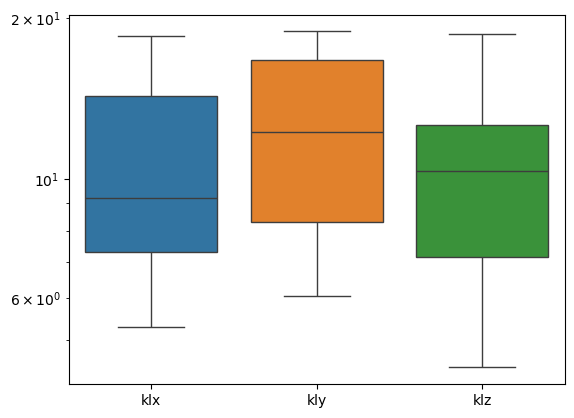

In [11]:
sns.boxplot(pd.DataFrame({
    "klx": data_aph1["KL_x"],
    "kly": data_aph1["KL_y"],
    "klz": data_aph1["KL_z"],
}))
plt.yscale("log")

On a bien le collapse attendu.

## Figure 

In [15]:
lambdas = best_models_aph1.keys()
paths = [model[:-4]+"_longrun_100.json" for model in best_models_aph1.values()]
data_aph1 = {}
for lam, path in zip(lambdas, paths):
    data_lam = pd.read_json(os.path.join(data_folder, path)).T
    data_lam = compute_metrics_lorenz(data_lam, compute_phy=True, eps=0.01)
    data_aph1[lam] = data_lam

TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'

In [11]:
lambdas = best_models_lip05.keys()
paths = [model[:-4]+"_longrun_100.json" for model in best_models_lip05.values()]
data_lip05 = {}
for lam, path in zip(lambdas, paths):
    data_lam = pd.read_json(os.path.join(data_folder, path)).T
    data_lam = compute_metrics_lorenz(data_lam, compute_phy=True, eps=0.01)
    data_lip05[lam] = data_lam

In [15]:
lambdas = best_models_lip1.keys()
paths = [model[:-4]+"_longrun_100.json" for model in best_models_lip1.values()]
data_lip1 = {}
for lam, path in zip(lambdas, paths):
    data_lam = pd.read_json(os.path.join(data_folder, path)).T
    data_lam = compute_metrics_lorenz(data_lam, compute_phy=True, eps=0.01)
    data_lip1[lam] = data_lam

In [12]:
lambdas = [l for l in range(1,21)]+[50,100]


In [13]:
path_node05 = "/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_aug_0.5_28_tf2kusqq/model_7.108e+01_longrun_100.json"
data_node05 = pd.read_json(path_node05).T
data_node05 = compute_metrics_lorenz(data_node05, compute_phy=True, eps=0.01)

# path_node1 = "/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_aug_1.0_1_lpirex33/model_4.397e+01_longrun_100.json"
# data_node1 = pd.read_json(path_node1).T
# data_node1 = compute_metrics_lorenz(data_node1, compute_phy=True, eps=0.01)

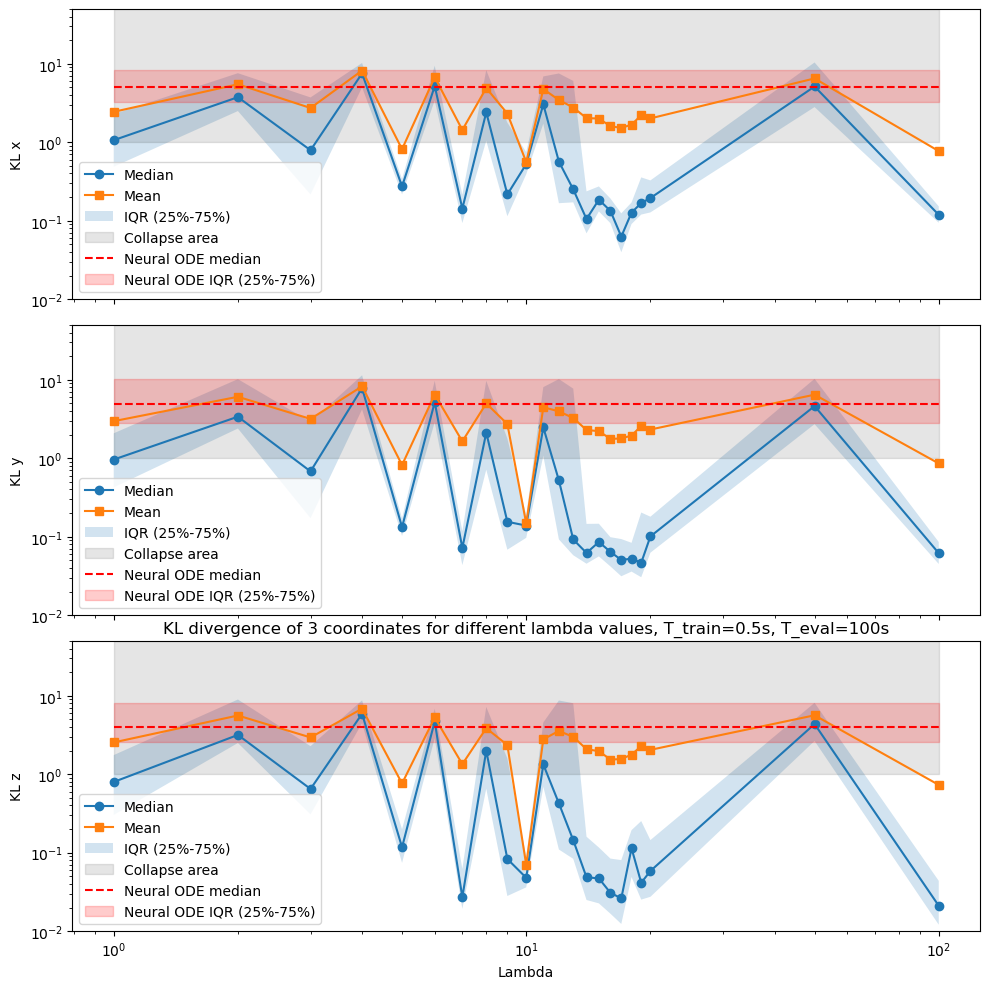

In [20]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

kl_keys = ['KL_x', 'KL_y', 'KL_z']
titles = ['KL x', 'KL y', 'KL z']

for i, (key, title) in enumerate(zip(kl_keys, titles)):
    ax = axs[i]
    
    medians = [data_lip05[k][key].median() for k in lambdas]
    means = [data_lip05[k][key].mean() for k in lambdas]
    q25 = [data_lip05[k][key].quantile(0.25) for k in lambdas]
    q75 = [data_lip05[k][key].quantile(0.75) for k in lambdas]
    
    ax.plot(lambdas, medians, label='Median', marker='o')
    ax.plot(lambdas, means, label='Mean', marker='s')
    ax.fill_between(lambdas, q25, q75, alpha=0.2, label='IQR (25%-75%)')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel(title)
    ax.set_ylim(1e-2, 5e1)
    #ax.hlines(1, xmin=0, xmax=110, color='black', linestyle='-')
    ax.fill_between([1, 100],1, 5e1, label="Collapse area", color='black', alpha=0.1)
    ax.hlines(y=data_node05[key].median(), xmin=1, xmax=100, color='red', linestyle='--', label='Neural ODE median')
    ax.fill_between([1, 100], 
                    data_node05[key].quantile(0.25), 
                    data_node05[key].quantile(0.75), 
                    color='red', alpha=0.2, label='Neural ODE IQR (25%-75%)')
    ax.legend()

axs[-1].set_xlabel('Lambda')

plt.tight_layout()
plt.title("KL divergence of 3 coordinates for different lambda values, T_train=0.5s, T_eval=100s")
plt.show()


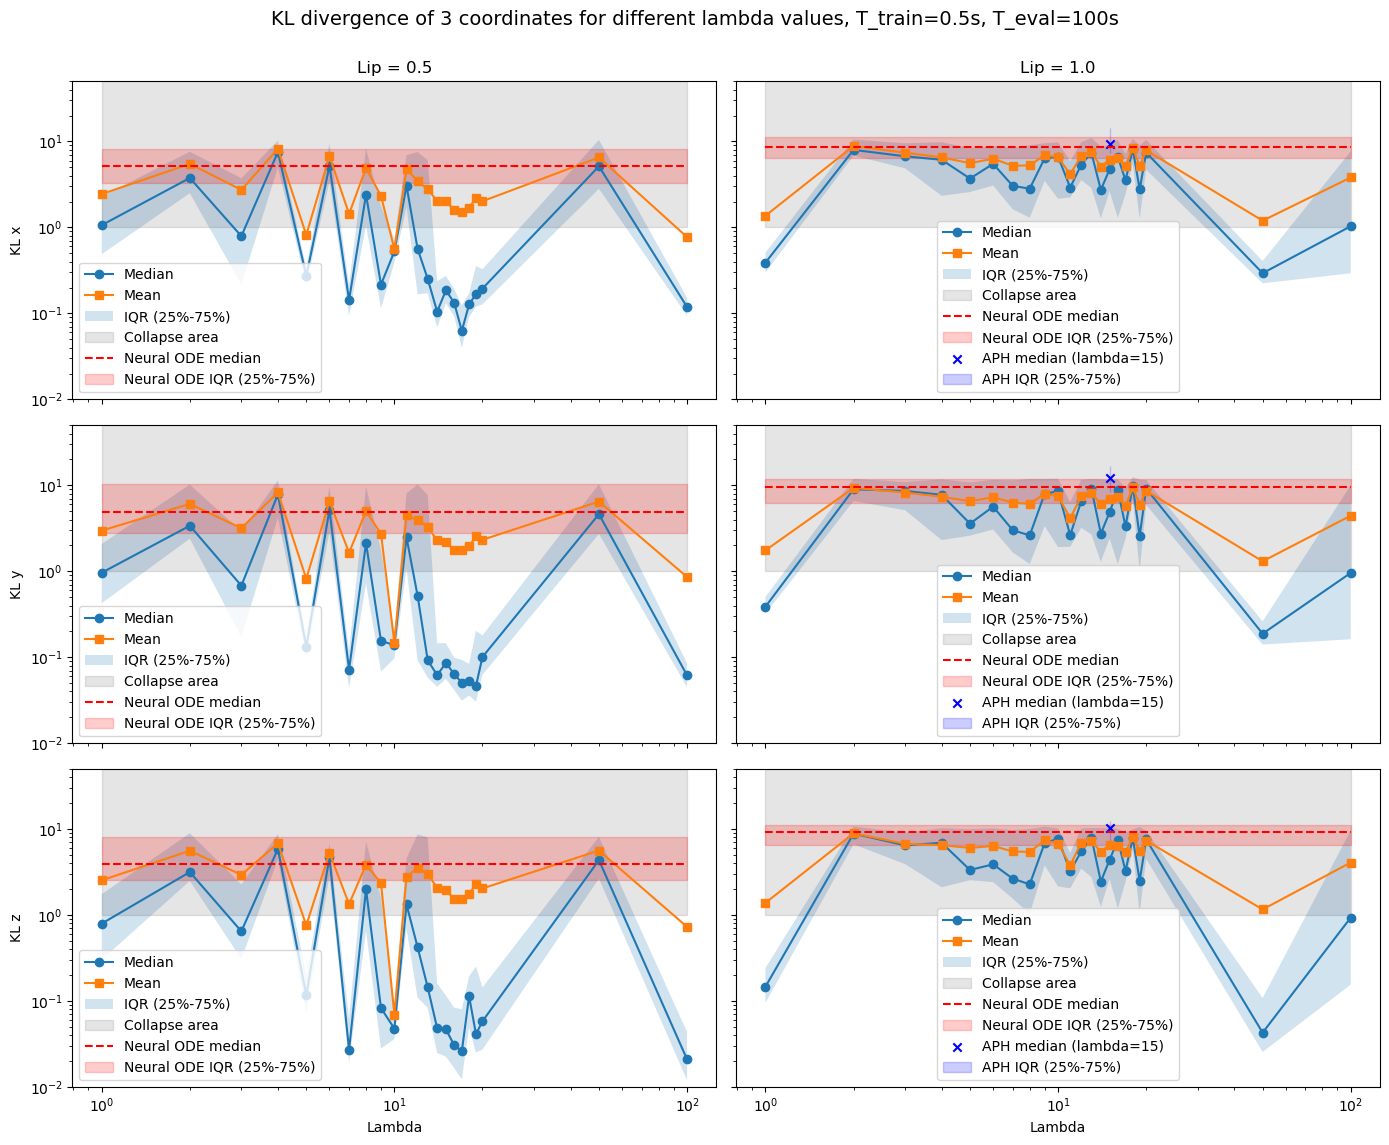

In [22]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 2, figsize=(14, 12), sharex=True, sharey=True)

kl_keys = ['KL_x', 'KL_y', 'KL_z']
titles = ['KL x', 'KL y', 'KL z']
datasets = [data_lip05, data_lip1]
node_datasets = [data_node05, data_node1]
col_titles = ['Lip = 0.5', 'Lip = 1.0']

for col, (data_lip, data_node, col_title) in enumerate(zip(datasets, node_datasets, col_titles)):
    for row, (key, title) in enumerate(zip(kl_keys, titles)):
        ax = axs[row, col]
        
        medians = [data_lip[k][key].median() for k in lambdas]
        means = [data_lip[k][key].mean() for k in lambdas]
        q25 = [data_lip[k][key].quantile(0.25) for k in lambdas]
        q75 = [data_lip[k][key].quantile(0.75) for k in lambdas]
        
        ax.plot(lambdas, medians, label='Median', marker='o')
        ax.plot(lambdas, means, label='Mean', marker='s')
        ax.fill_between(lambdas, q25, q75, alpha=0.2, label='IQR (25%-75%)')
        
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_ylim(1e-2, 5e1)
        ax.fill_between([1, 100], 1, 5e1, label="Collapse area", color='black', alpha=0.1)
        
        ax.hlines(y=data_node[key].median(), xmin=1, xmax=100, color='red', linestyle='--', label='Neural ODE median')
        ax.fill_between([1, 100], 
                        data_node[key].quantile(0.25), 
                        data_node[key].quantile(0.75), 
                        color='red', alpha=0.2, label='Neural ODE IQR (25%-75%)')

        if col==1:
            ax.scatter([15], data_aph1[15][key].median(), marker='x', color='blue', label='APH median (lambda=15)')
            ax.fill_between([15], 
                            data_aph1[15][key].quantile(0.25), 
                            data_aph1[15][key].quantile(0.75), 
                            color='blue', alpha=0.2, label='APH IQR (25%-75%)')
        
        if col == 0:
            ax.set_ylabel(title)
        if row == 0:
            ax.set_title(col_title)
        if row == 2:
            ax.set_xlabel('Lambda')
        
        ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("KL divergence of 3 coordinates for different lambda values, T_train=0.5s, T_eval=100s", fontsize=14)
plt.show()


# $\lambda$ progressive

In [73]:
def get_best_models_lambda_prog(model_folders):
    best_models = {}
    for folder in model_folders:
        # open hyperparameters to get lambda, tau
        hyperparams_path = os.path.join(data_folder, folder, 'hyperparameters.json')
        with open(hyperparams_path, 'r') as f:
            hyperparams = json.load(f)
        lambda_value = hyperparams['lambda0']
        tau_value = hyperparams['tau_2']
        if tau_value != 0.0: # progressive lambda 
            models_list = os.listdir(os.path.join(data_folder, folder))
            models_list = [model for model in models_list if model.endswith('.eqx')] # filter for model files
            mse_list = [float(model[6:-4]) for model in models_list]  # extract mse from filenames
            idx_best_mse = np.argmin(mse_list)
            if  mse_list[idx_best_mse] < 200:
                best_models[f"{lambda_value}+{tau_value}"] = folder+"/"+models_list[idx_best_mse]
    return best_models

In [74]:
best_models_lip05_prog = get_best_models_lambda_prog(lip_models_folders05)
best_models_aph05_prog = get_best_models_lambda_prog(aph_models_folders05)
print(len(best_models_lip05_prog), len(best_models_aph05_prog))

9 9


In [16]:
best_models_lipYX05_prog = get_best_models_lambda_prog(lipYX_models_folders05)
len(best_models_lipYX05_prog)

9

In [75]:
best_models_aph05_prog

{'10.0+1.0': 'none_Fa_aug_0.5_95_q3q9xbrk/model_1.278e+02.eqx',
 '1.0+100.0': 'none_Fa_aug_0.5_94_q3q9xbrk/model_8.151e+01.eqx',
 '1.0+1.0': 'none_Fa_aug_0.5_92_q3q9xbrk/model_1.914e+02.eqx',
 '1.0+10.0': 'none_Fa_aug_0.5_93_q3q9xbrk/model_1.020e+02.eqx',
 '100.0+1.0': 'none_Fa_aug_0.5_98_q3q9xbrk/model_1.122e+02.eqx',
 '100.0+10.0': 'none_Fa_aug_0.5_99_q3q9xbrk/model_8.946e+01.eqx',
 '100.0+100.0': 'none_Fa_aug_0.5_117_vm9ntlj3/model_7.511e+01.eqx',
 '10.0+10.0': 'none_Fa_aug_0.5_96_q3q9xbrk/model_8.008e+01.eqx',
 '10.0+100.0': 'none_Fa_aug_0.5_97_q3q9xbrk/model_8.424e+01.eqx'}

This time all configurations produce models that do not collapse every time.

In [139]:
# save json
with open(os.path.join(data_folder, 'best_models_lip05_prog.json'), 'w') as f:
    json.dump(best_models_lip05_prog, f)
with open(os.path.join(data_folder, 'best_models_aph05_prog.json'), 'w') as f:
    json.dump(best_models_aph05_prog, f)

In [93]:
with open(os.path.join(data_folder, 'best_models_lipYX05_prog.json'), 'w') as f:
    json.dump(best_models_lipYX05_prog, f)

In [23]:
from collections import defaultdict
paths = [model[:-4]+"_longrun_100.json" for model in best_models_lip05_prog.values()]
data_lip05_prog = defaultdict(dict)
for key, path in zip(best_models_lip05_prog.keys(), paths):
    lam, tau = key.split('+')
    data_lam = pd.read_json(os.path.join(data_folder, path)).T
    data_lam = compute_metrics_lorenz(data_lam, compute_phy=True, eps=0.01)
    data_lip05_prog[lam][tau] = data_lam

In [18]:
from collections import defaultdict
paths = [model[:-4]+"_longrun_100.json" for model in best_models_aph05_prog.values()]
data_aph05_prog = defaultdict(dict)
for key, path in zip(best_models_aph05_prog.keys(), paths):
    lam, tau = key.split('+')
    data_lam = pd.read_json(os.path.join(data_folder, path)).T
    data_lam = compute_metrics_lorenz(data_lam, compute_phy=True, eps=0.01)
    data_aph05_prog[lam][tau] = data_lam

In [25]:
lambdas0 = [1.0,10.0,100.0]
taus = [1.0, 10.0, 100.0]

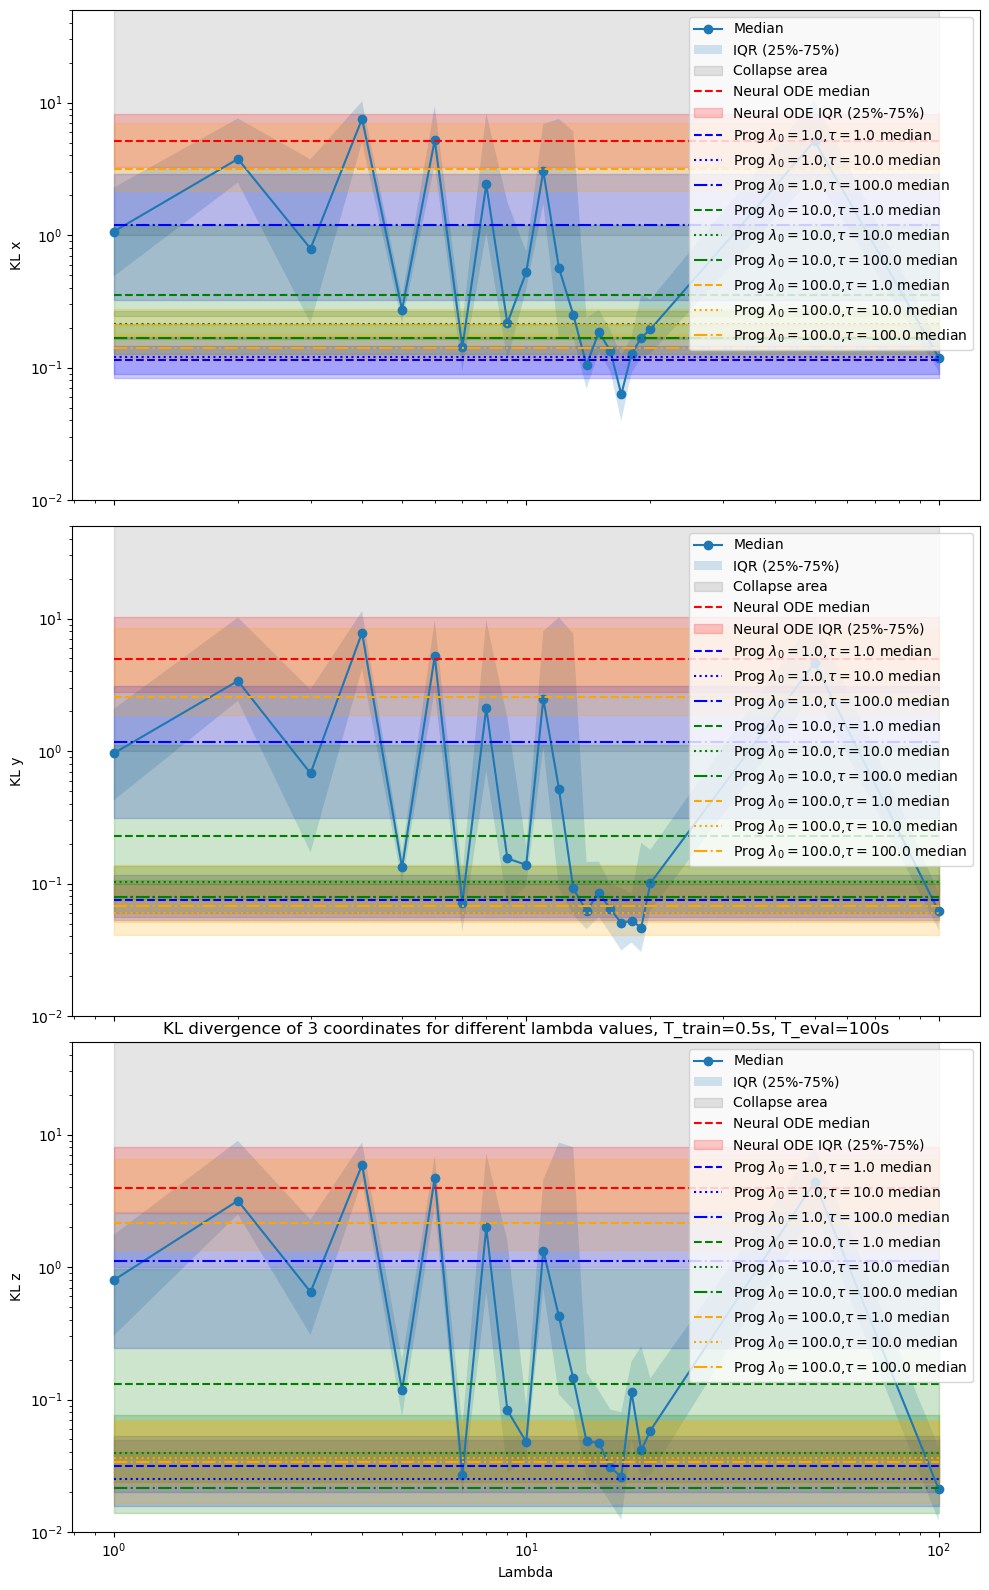

In [153]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(10, 16), sharex=True)

kl_keys = ['KL_x', 'KL_y', 'KL_z']
titles = ['KL x', 'KL y', 'KL z']

for i, (key, title) in enumerate(zip(kl_keys, titles)):
    ax = axs[i]
    
    medians = [data_lip05[k][key].median() for k in lambdas]
    means = [data_lip05[k][key].mean() for k in lambdas]
    q25 = [data_lip05[k][key].quantile(0.25) for k in lambdas]
    q75 = [data_lip05[k][key].quantile(0.75) for k in lambdas]
    
    ax.plot(lambdas, medians, label='Median', marker='o')
    #ax.plot(lambdas, means, label='Mean', marker='s')
    ax.fill_between(lambdas, q25, q75, alpha=0.2, label='IQR (25%-75%)')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel(title)
    ax.set_ylim(1e-2, 5e1)
    #ax.hlines(1, xmin=0, xmax=110, color='black', linestyle='-')
    ax.fill_between([1, 100],1, 5e1, label="Collapse area", color='black', alpha=0.1)
    ax.hlines(y=data_node05[key].median(), xmin=1, xmax=100, color='red', linestyle='--', label='Neural ODE median')
    ax.fill_between([1, 100], 
                    data_node05[key].quantile(0.25), 
                    data_node05[key].quantile(0.75), 
                    color='red', alpha=0.2, label='Neural ODE IQR (25%-75%)')
    # plot progressive lambda
    for l in ["1.0","10.0","100.0"]:
        color = 'blue' if l == "1.0" else 'green' if l == "10.0" else 'orange'
        for tau in ["1.0","10.0","100.0"]:
            linestyle = '--' if tau == "1.0" else ':' if tau == "10.0" else '-.'
            if l in data_lip05_prog and tau in data_lip05_prog[l]:
                ax.hlines(data_lip05_prog[l][tau][key].median(), xmin=1, xmax=100, color=color, linestyle=linestyle, label=fr'Prog $\lambda_0={l}$,$\tau=${tau} median')
                ax.fill_between([1,100], 
                                data_lip05_prog[l][tau][key].quantile(0.25), 
                                data_lip05_prog[l][tau][key].quantile(0.75), 
                                color=color, alpha=0.2) #, label=rf'Prog $\tau=${tau} IQR (25%-75%)')
            #legend color and linestyles
   
    ax.legend()



axs[-1].set_xlabel('Lambda')

plt.tight_layout()
plt.title("KL divergence of 3 coordinates for different lambda values, T_train=0.5s, T_eval=100s")
plt.show()


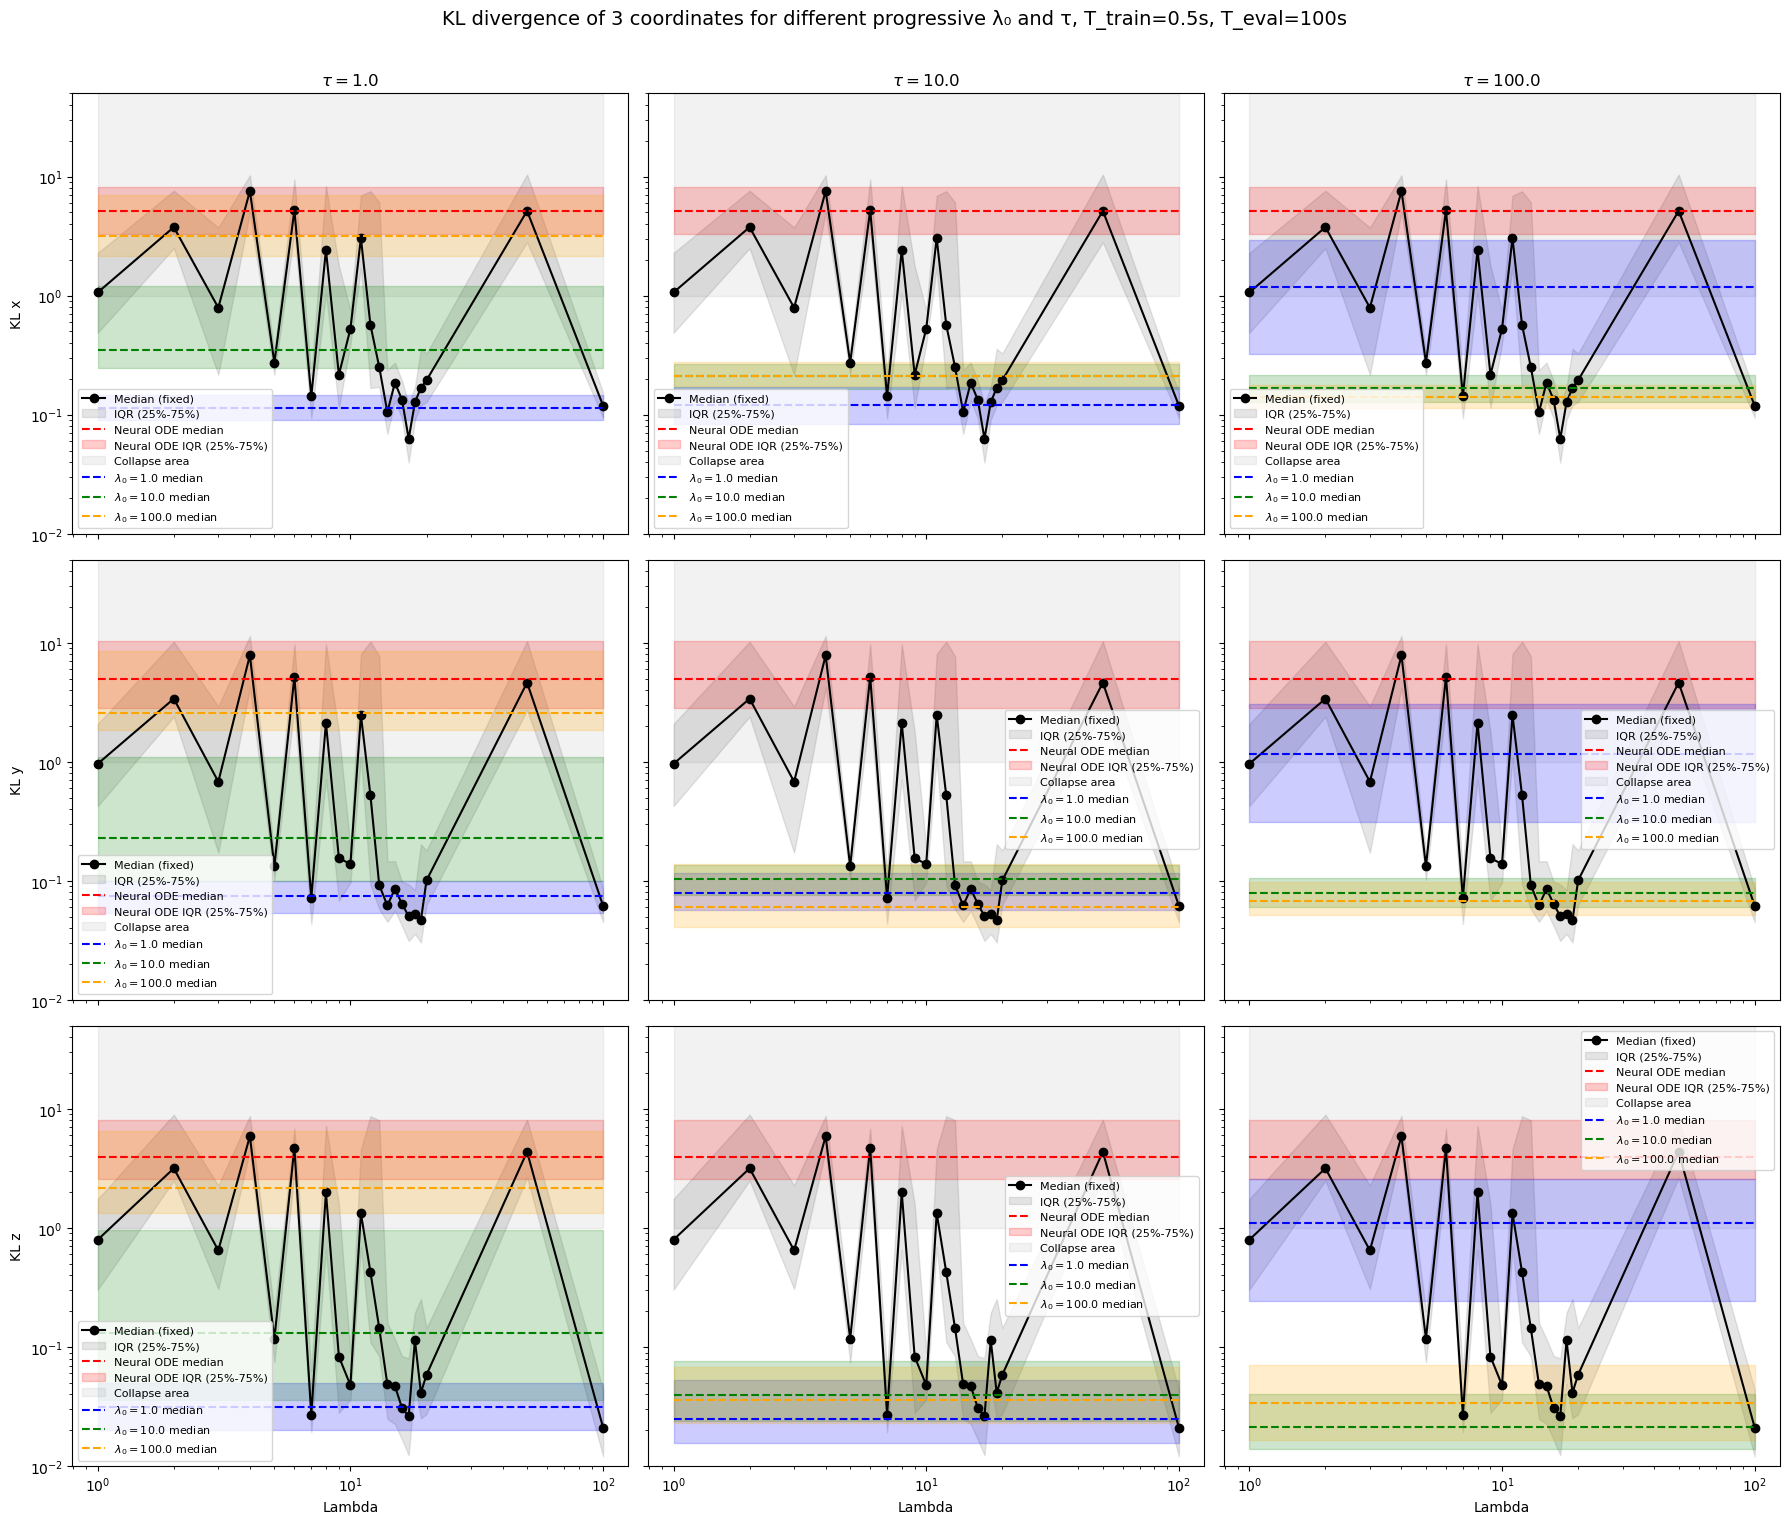

In [28]:
import matplotlib.pyplot as plt

taus = ["1.0", "10.0", "100.0"]
colors = {"1.0": "blue", "10.0": "green", "100.0": "orange"}
linestyles = {"1.0": "--", "10.0": ":", "100.0": "-."}

kl_keys = ['KL_x', 'KL_y', 'KL_z']
titles = ['KL x', 'KL y', 'KL z']

fig, axs = plt.subplots(3, 3, figsize=(18, 16), sharex=True, sharey=True)

for col, tau in enumerate(taus):
    for row, (key, title) in enumerate(zip(kl_keys, titles)):
        ax = axs[row, col]
        
        # Base lip=0.5 results
        medians = [data_lip05[k][key].median() for k in lambdas]
        q25 = [data_lip05[k][key].quantile(0.25) for k in lambdas]
        q75 = [data_lip05[k][key].quantile(0.75) for k in lambdas]
        
        ax.plot(lambdas, medians, label='Median (fixed)', marker='o', color='black')
        ax.fill_between(lambdas, q25, q75, alpha=0.2, label='IQR (25%-75%)', color='gray')
        
        # Neural ODE reference
        ax.hlines(y=data_node05[key].median(), xmin=1, xmax=100, color='red', linestyle='--', label='Neural ODE median')
        ax.fill_between([1, 100], 
                        data_node05[key].quantile(0.25), 
                        data_node05[key].quantile(0.75), 
                        color='red', alpha=0.2, label='Neural ODE IQR (25%-75%)')

        # Collapse area
        ax.fill_between([1, 100], 1, 5e1, label="Collapse area", color='black', alpha=0.05)

        # Progressive lambda results (l=1, 10, 100)
        for l in ["1.0", "10.0", "100.0"]:
            if l in data_lip05_prog and tau in data_lip05_prog[l]:
                prog_data = data_lip05_prog[l][tau][key]
                ax.hlines(prog_data.median(), xmin=1, xmax=100, color=colors[l], linestyle='--',
                          label=fr'$\lambda_0={l}$ median')
                ax.fill_between([1, 100],
                                prog_data.quantile(0.25),
                                prog_data.quantile(0.75),
                                color=colors[l], alpha=0.2)

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_ylim(1e-2, 5e1)
        
        if col == 0:
            ax.set_ylabel(title)
        if row == 2:
            ax.set_xlabel('Lambda')
        if row == 0:
            ax.set_title(f"$\\tau = {tau}$")

        ax.legend(fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("KL divergence of 3 coordinates for different progressive λ₀ and τ, T_train=0.5s, T_eval=100s", fontsize=14)
plt.show()


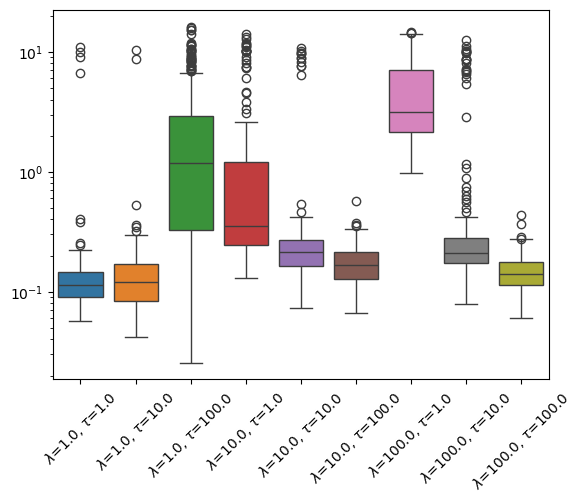

In [163]:
# 2 box plot for each method (aph, lip), x axis=lambda and tau, y= KL divergence    
df = pd.DataFrame()
for l in ["1.0", "10.0", "100.0"]:
    for tau in ["1.0", "10.0", "100.0"]:
        df[fr"$\lambda$={l}, $\tau$={tau}"] = data_lip05_prog[l][tau]["KL_x"].values

sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.yscale('log')

In [1]:
data_lip05

NameError: name 'data_lip05' is not defined

/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_35628/2352391378.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_35628/2352391378.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_35628/2352391378.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_35628/2352391378.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, 

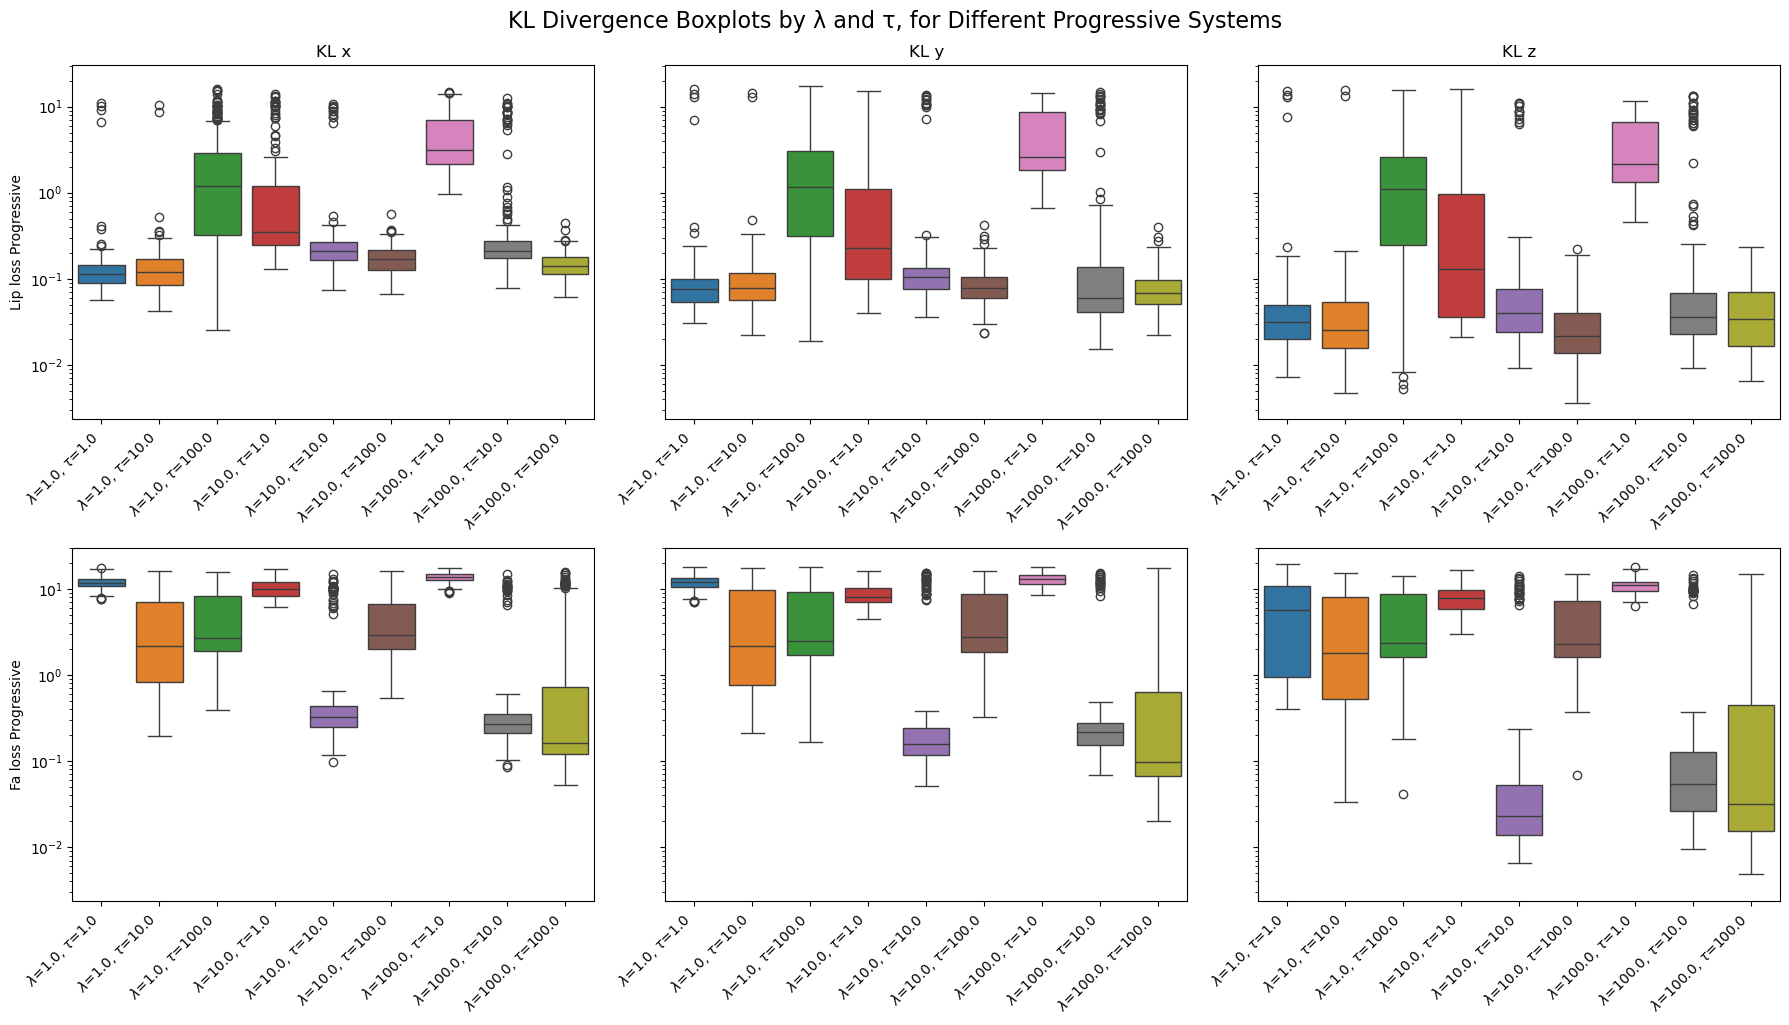

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

lambdas = ["1.0", "10.0", "100.0"]
taus = ["1.0", "10.0", "100.0"]
kl_keys = ["KL_x", "KL_y", "KL_z"]
titles = ["KL x", "KL y", "KL z"]

fig, axs = plt.subplots(2, 3, figsize=(18, 10), sharey=True)

datasets = [data_lip05_prog, data_aph05_prog]
row_titles = ['Lip loss Progressive', 'Fa loss Progressive']

for row, (dataset, row_title) in enumerate(zip(datasets, row_titles)):
    for col, (key, title) in enumerate(zip(kl_keys, titles)):
        df = pd.DataFrame()
        for l in lambdas:
            for tau in taus:
                label = fr"$\lambda$={l}, $\tau$={tau}"
                df[label] = dataset[l][tau][key].values

        ax = axs[row, col]
        sns.boxplot(data=df, ax=ax)
        ax.set_yscale('log')
        #ax.set_ticks(len(lambdas) * len(taus))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        if row == 0:
            ax.set_title(title)
        if col == 0:
            ax.set_ylabel(row_title)

plt.tight_layout()
plt.suptitle("KL Divergence Boxplots by λ and τ, for Different Progressive Systems", fontsize=16, y=1.02)
plt.show()


Best models comparison

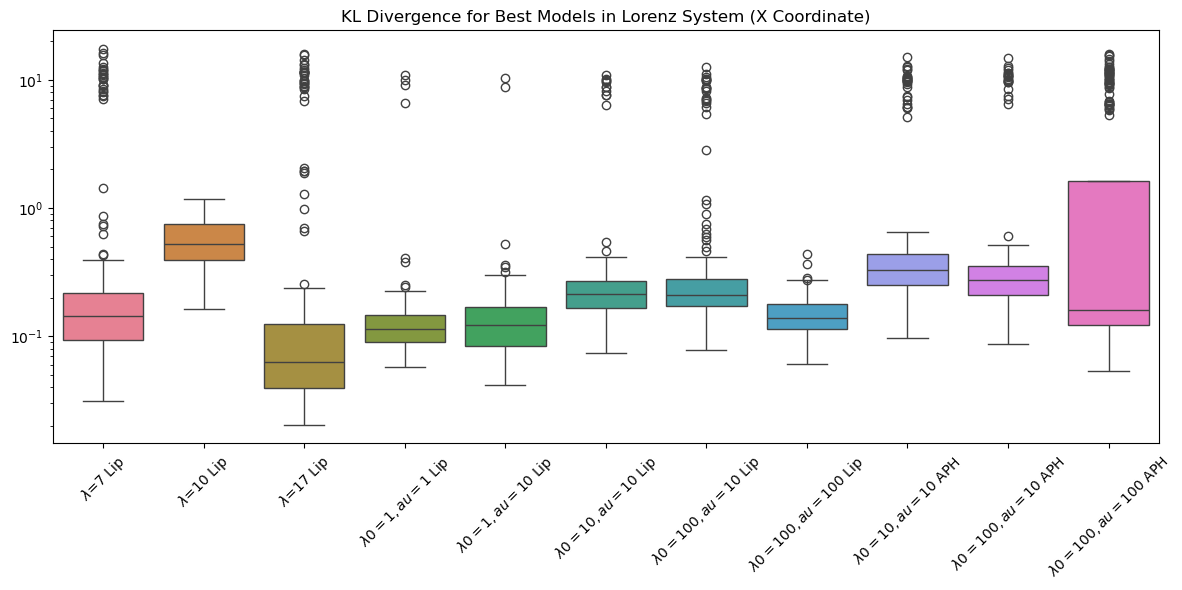

In [184]:
plt.figure(figsize=(12, 6))
df_bestX = pd.DataFrame({
    # lambda fixed
    r"$\lambda$=7 Lip": data_lip05[7][f"KL_x"],
    r"$\lambda$=10 Lip": data_lip05[10][f"KL_x"],
    r"$\lambda$=17 Lip": data_lip05[17][f"KL_x"],
    # lambda progressive
    "$\lambda0=1, \tau=1$ Lip": data_lip05_prog["1.0"]["1.0"][f"KL_x"], 
    "$\lambda0=1, \tau=10$ Lip": data_lip05_prog["1.0"]["10.0"][f"KL_x"], 
    "$\lambda0=10, \tau=10$ Lip": data_lip05_prog["10.0"]["10.0"][f"KL_x"],
    "$\lambda0=100, \tau=10$ Lip": data_lip05_prog["100.0"]["10.0"][f"KL_x"],
    "$\lambda0=100, \tau=100$ Lip": data_lip05_prog["100.0"]["100.0"][f"KL_x"],
    "$\lambda0=10, \tau=10$ APH": data_aph05_prog["10.0"]["10.0"][f"KL_x"], 
    "$\lambda0=100, \tau=10$ APH": data_aph05_prog["100.0"]["10.0"][f"KL_x"], 
    "$\lambda0=100, \tau=100$ APH": data_aph05_prog["100.0"]["100.0"][f"KL_x"]
})

sns.boxplot(data=df_bestX)
plt.yscale('log')
plt.xticks(rotation=45)
plt.title("KL Divergence for Best Models in Lorenz System (X Coordinate)")
plt.tight_layout()

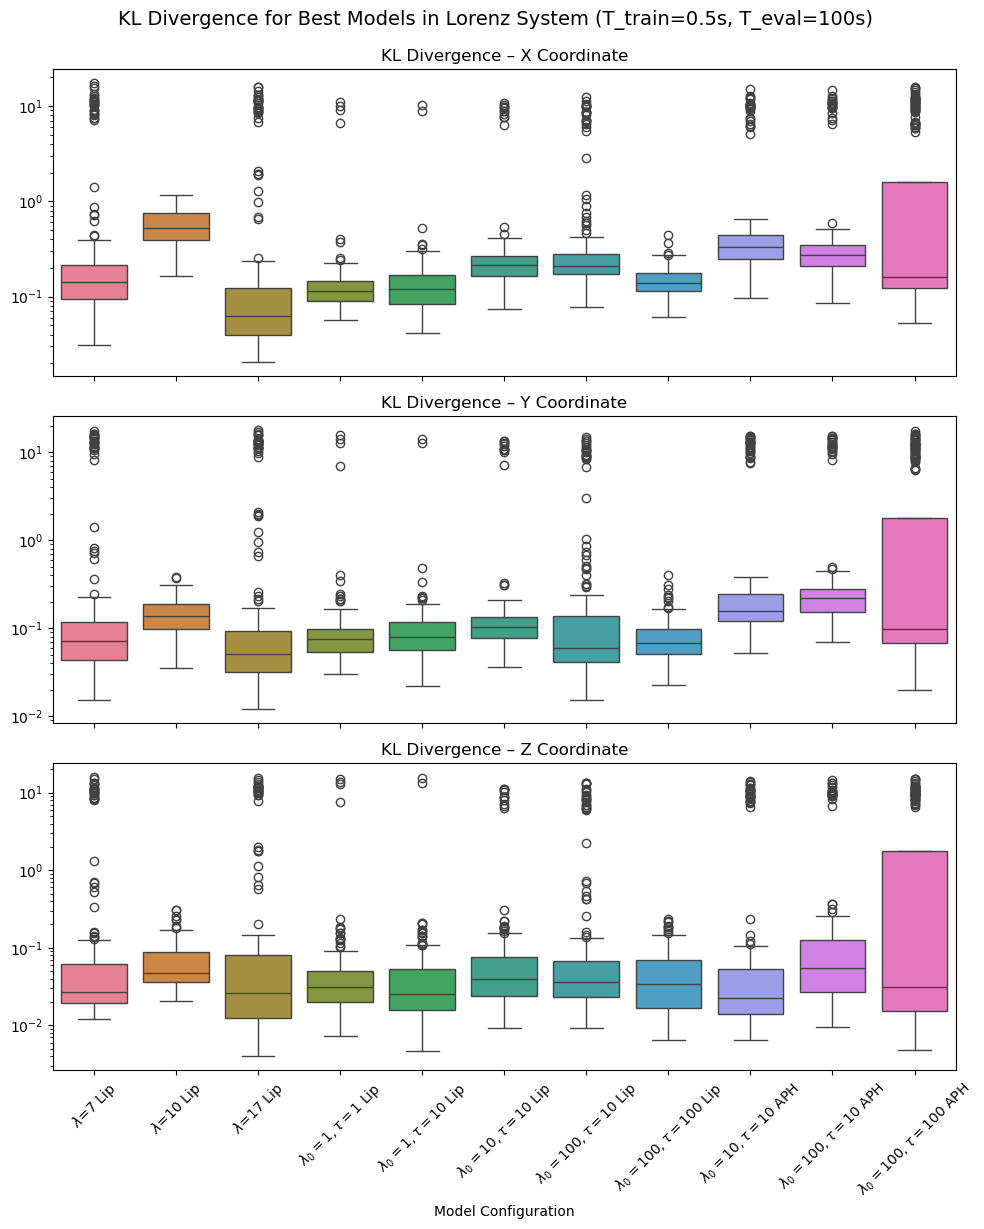

In [185]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

kl_keys = ['KL_x', 'KL_y', 'KL_z']
titles = ['X Coordinate', 'Y Coordinate', 'Z Coordinate']

fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for i, (key, title) in enumerate(zip(kl_keys, titles)):
    df = pd.DataFrame({
        # Fixed lambda (Lip)
        r"$\lambda$=7 Lip": data_lip05[7][key],
        r"$\lambda$=10 Lip": data_lip05[10][key],
        r"$\lambda$=17 Lip": data_lip05[17][key],
        # Progressive lambda (Lip)
        "$\lambda_0=1, \\tau=1$ Lip": data_lip05_prog["1.0"]["1.0"][key],
        "$\lambda_0=1, \\tau=10$ Lip": data_lip05_prog["1.0"]["10.0"][key],
        "$\lambda_0=10, \\tau=10$ Lip": data_lip05_prog["10.0"]["10.0"][key],
        "$\lambda_0=100, \\tau=10$ Lip": data_lip05_prog["100.0"]["10.0"][key],
        "$\lambda_0=100, \\tau=100$ Lip": data_lip05_prog["100.0"]["100.0"][key],
        # Progressive lambda (APH)
        "$\lambda_0=10, \\tau=10$ APH": data_aph05_prog["10.0"]["10.0"][key],
        "$\lambda_0=100, \\tau=10$ APH": data_aph05_prog["100.0"]["10.0"][key],
        "$\lambda_0=100, \\tau=100$ APH": data_aph05_prog["100.0"]["100.0"][key],
    })

    sns.boxplot(data=df, ax=axs[i])
    axs[i].set_yscale('log')
    axs[i].set_title(f"KL Divergence – {title}")
    axs[i].tick_params(axis='x', rotation=45)

axs[-1].set_xlabel("Model Configuration")
plt.tight_layout()
plt.suptitle("KL Divergence for Best Models in Lorenz System (T_train=0.5s, T_eval=100s)", fontsize=14, y=1.02)
plt.show()


Jacobian norms associated

In [2]:
import jax
import jax.numpy as jnp
from datasets import *
from networks import * 
from forecasters import Forecaster

In [3]:
def make_jacobian_norm_fn(model):
    """Returns a batched, JIT-compiled function to compute Jacobian norms."""
    # JIT compile jacobian computation
    jac_fn = jax.jit(jax.jacfwd(model))

    def jacobian_norm(y0):
        return jnp.linalg.norm(jac_fn(y0))

    return jax.vmap(jacobian_norm)  # vectorized over batch of y0

def compute_jacobian_test(model, y, bool_true=False):
    if bool_true:
        jacobian_norms_fn = make_jacobian_norm_fn(model)
    else:
        jacobian_norms_fn = make_jacobian_norm_fn(model.model_aug)
    return jacobian_norms_fn(y)  # y shape: (N, features)

In [4]:
def load_model_40s(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, data_integration_method="RK4", dt_num=0.5, duration=40):
    """Compute trajectory losses and Fa loss for a given model, on its duration of training data."""
    # load test data 
    _, _, test = init_dataloaders(dataset_name, data_integration_method, os.path.join(data_path, dataset_name+str(duration)), dt_num=dt_num, duration=duration)

    # load model
    model_path = os.path.join(data_path, f"{exp_name}/{model_name}")
    print(model_path)
    with open(os.path.join(data_path, f'{exp_name}/hyperparameters.json'), 'r') as f:
        hyperparameters_dict = json.load(f)
    min_op = hyperparameters_dict['min_op']
    dt = hyperparameters_dict["dt"]
    dt_factor = int(dt/test.dataset.dt)
    print(dt, dt_factor)
    if dataset_name == 'pendulum':
        if model_phy_option == 'true': # true damped pendulum
            model_phy = PendulumParamPDE(is_damped=True, params=test.dataset.params, is_true=True)
        elif model_phy_option == 'complete': # damped pendulum
            model_phy = PendulumParamPDE(is_damped=True)
        else: 
            model_phy = PendulumParamPDE(is_damped=False)
    
        with open(model_path, "rb") as f:
            hyperparams = json.loads(f.readline().decode())
            mkey = jax.random.PRNGKey(0)
            model_aug = MLP(key=mkey, state_c=2, hidden=200)
            net = Forecaster(
                model_phy=model_phy,
                model_aug=model_aug,
                is_augmented=model_aug_option,
                is_phy=model_phy_option,
                dt=dt,
                num_steps=int(test.dataset.num_steps/dt_factor),
                integration_method=integration_method, # error scheme exp
            )
            model = eqx.tree_deserialise_leaves(f, net)
    elif dataset_name == "lorenz":
        model_phy = None # Neural ODE 
        with open(model_path, "rb") as f:
            hyperparams = json.loads(f.readline().decode())
            mkey, ikey = jax.random.split(jax.random.PRNGKey(0))
            model_aug = MLP(key=mkey, state_c=3, hidden=200)
            net = Forecaster(
                model_phy=model_phy,
                model_aug=model_aug,
                is_augmented=model_aug_option,
                is_phy=model_phy_option,
                dt=dt_factor * test.dataset.dt, # enabling comparison with GT for error scheme experiment 
                num_steps=int(test.dataset.num_steps / dt_factor), 
                integration_method=integration_method, # RK2 for error scheme experiment
            )
            model = eqx.tree_deserialise_leaves(f, net)
    return model

In [22]:
# load models 
models_lip05 = {}
# iterate over dictionnary 
for key, model in best_models_lip05.items():
    exp_name, model_name = model.split('/')
    models_lip05[key] = load_model_40s(model_name, exp_name, data_folder, "none_Fa_prime_supX", True, "lorenz", "RK4", dt_num=0.01, duration=100)


/Users/mayajanvier/jax-phynity/data/lorenz_curriculum_gridsearch/none_Fa_prime_supX_aug_0.5_68_q3q9xbrk/model_6.988e+01.eqx
0.01 1
/Users/mayajanvier/jax-phynity/data/lorenz_curriculum_gridsearch/none_Fa_prime_supX_aug_0.5_69_q3q9xbrk/model_6.805e+01.eqx
0.01 1
/Users/mayajanvier/jax-phynity/data/lorenz_curriculum_gridsearch/none_Fa_prime_supX_aug_0.5_56_q3q9xbrk/model_7.975e+01.eqx
0.01 1
/Users/mayajanvier/jax-phynity/data/lorenz_curriculum_gridsearch/none_Fa_prime_supX_aug_0.5_57_q3q9xbrk/model_9.040e+01.eqx
0.01 1
/Users/mayajanvier/jax-phynity/data/lorenz_curriculum_gridsearch/none_Fa_prime_supX_aug_0.5_62_q3q9xbrk/model_6.911e+01.eqx
0.01 1
/Users/mayajanvier/jax-phynity/data/lorenz_curriculum_gridsearch/none_Fa_prime_supX_aug_0.5_63_q3q9xbrk/model_7.090e+01.eqx
0.01 1
/Users/mayajanvier/jax-phynity/data/lorenz_curriculum_gridsearch/none_Fa_prime_supX_aug_0.5_51_q3q9xbrk/model_8.768e+01.eqx
0.01 1
/Users/mayajanvier/jax-phynity/data/lorenz_curriculum_gridsearch/none_Fa_prime_supX

In [23]:
models_aph05_prog = defaultdict(dict)
# iterate over dictionnary
for key_lambda in ["1.0", "10.0", "100.0"]:
    for key_tau in ["1.0", "10.0", "100.0"]:   
        exp_name, model_name = best_models_aph05_prog[key_lambda+"+"+key_tau].split('/')
        models_aph05_prog[key_lambda][key_tau] = load_model_40s(model_name, exp_name, data_folder, "none_Fa_prime_supX", True, "lorenz", "RK4", dt_num=0.01, duration=100)

models_lip05_prog = defaultdict(dict)
# iterate over dictionnary
for key_lambda in ["1.0", "10.0", "100.0"]:
    for key_tau in ["1.0", "10.0", "100.0"]:   
        exp_name, model_name = best_models_lip05_prog[key_lambda+"+"+key_tau].split('/')
        models_lip05_prog[key_lambda][key_tau] = load_model_40s(model_name, exp_name, data_folder, "none_Fa_prime_supX", True, "lorenz", "RK4", dt_num=0.01, duration=100)


/Users/mayajanvier/jax-phynity/data/lorenz_curriculum_gridsearch/none_Fa_aug_0.5_92_q3q9xbrk/model_1.914e+02.eqx
0.01 1
/Users/mayajanvier/jax-phynity/data/lorenz_curriculum_gridsearch/none_Fa_aug_0.5_93_q3q9xbrk/model_1.020e+02.eqx
0.01 1
/Users/mayajanvier/jax-phynity/data/lorenz_curriculum_gridsearch/none_Fa_aug_0.5_94_q3q9xbrk/model_8.151e+01.eqx
0.01 1
/Users/mayajanvier/jax-phynity/data/lorenz_curriculum_gridsearch/none_Fa_aug_0.5_95_q3q9xbrk/model_1.278e+02.eqx
0.01 1
/Users/mayajanvier/jax-phynity/data/lorenz_curriculum_gridsearch/none_Fa_aug_0.5_96_q3q9xbrk/model_8.008e+01.eqx
0.01 1
/Users/mayajanvier/jax-phynity/data/lorenz_curriculum_gridsearch/none_Fa_aug_0.5_97_q3q9xbrk/model_8.424e+01.eqx
0.01 1
/Users/mayajanvier/jax-phynity/data/lorenz_curriculum_gridsearch/none_Fa_aug_0.5_98_q3q9xbrk/model_1.122e+02.eqx
0.01 1
/Users/mayajanvier/jax-phynity/data/lorenz_curriculum_gridsearch/none_Fa_aug_0.5_99_q3q9xbrk/model_8.946e+01.eqx
0.01 1
/Users/mayajanvier/jax-phynity/data/lore

In [24]:
def get_yL_states10s(dataframe, type='lorenz', bool_true=True):
    y_list = []
    if type == "pendulum":
        for i,data in enumerate(dataframe):
            states = jnp.array(data['states'])
            for j in range(states.shape[2]):
                y_list.append(states[0,:,j])
            # if i == 24:
            #     break
    elif type == "lorenz":
        if bool_true:
            states = dataframe['y_true']
        else:
            states = dataframe['y_pred']
        for i in range(states.shape[0]):
            #print(states.shape, states[i].shape)
            for j in range(int(10.01/0.01)):
            #print(states.shape)
                y_list.append(states[i][:,j])
    y_list = np.array(y_list)
    print(y_list.shape, y_list[0].shape)
    return y_list

yL_10s = get_yL_states10s(data_lip05[7])

(200200, 3) (3,)


In [25]:
def get_yL_states50s(dataframe, type='lorenz', bool_true=True):
    y_list = []
    if type == "pendulum":
        for i,data in enumerate(dataframe):
            states = jnp.array(data['states'])
            for j in range(states.shape[2]):
                y_list.append(states[0,:,j])
            # if i == 24:
            #     break
    elif type == "lorenz":
        if bool_true:
            states = dataframe['y_true']
        else:
            states = dataframe['y_pred']
        for i in range(states.shape[0]):
            #print(states.shape, states[i].shape)
            for j in range(int(50.01/0.01)):
            #print(states.shape)
                y_list.append(states[i][:,j])
    y_list = np.array(y_list)
    print(y_list.shape, y_list[0].shape)
    return y_list

yL_50s = get_yL_states50s(data_lip05[7])

(1000200, 3) (3,)


In [80]:
plt.figure(figsize=(12, 6))
df_jac_norms = pd.DataFrame({
    # lambda fixed
    r"$\lambda$=7 Lip": compute_jacobian_test(models_lip05[7], yL_10s),
    r"$\lambda$=10 Lip": compute_jacobian_test(models_lip05[10], yL_10s),
    r"$\lambda$=17 Lip": compute_jacobian_test(models_lip05[17], yL_10s),
    # lambda progressive
    "$\lambda0=1, \tau=1$ Lip": compute_jacobian_test(models_lip05_prog["1.0"]["1.0"], yL_10s),
    "$\lambda0=1, \tau=10$ Lip": compute_jacobian_test(models_lip05_prog["1.0"]["10.0"], yL_10s),
    "$\lambda0=10, \tau=10$ Lip": compute_jacobian_test(models_lip05_prog["10.0"]["10.0"], yL_10s),
    "$\lambda0=100, \tau=10$ Lip": compute_jacobian_test(models_lip05_prog["100.0"]["10.0"], yL_10s),
    "$\lambda0=100, \tau=100$ Lip": compute_jacobian_test(models_lip05_prog["100.0"]["100.0"], yL_10s),
    "$\lambda0=10, \tau=10$ APH": compute_jacobian_test(models_aph05_prog["10.0"]["10.0"], yL_10s),
    "$\lambda0=100, \tau=10$ APH": compute_jacobian_test(models_aph05_prog["100.0"]["10.0"], yL_10s),
    "$\lambda0=100, \tau=100$ APH": compute_jacobian_test(models_aph05_prog["100.0"]["100.0"], yL_10s)
})

<Figure size 1200x600 with 0 Axes>

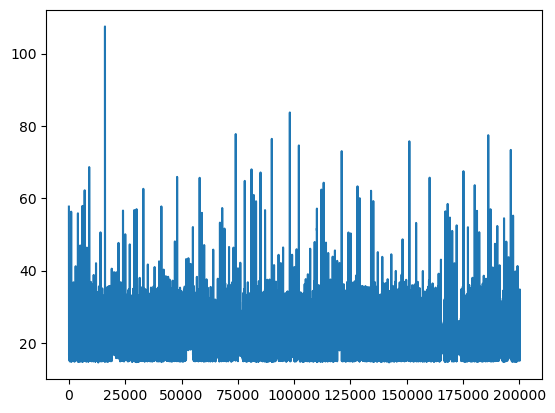

In [26]:
xmax = yL_10s[:,0].max()
ymax = yL_10s[:,1].max()
zmin = yL_10s[:,2].min()
sigma, rho, beta = 10, 28, 8/3

L_frob_lorenz = np.sqrt(sigma**2+sigma**2+ (rho-zmin)**2+1+xmax**2+ymax**2+ xmax**2+ beta**2)
L_frob_lorenz

L_effective = np.sqrt(sigma**2+sigma**2+ (rho-yL_10s[:,2])**2+1+yL_10s[:,0]**2+yL_10s[:,1]**2+ yL_10s[:,0]**2+ beta**2)
plt.plot(L_effective, label="Effective Lipschitz")
L_effective.max()

# true lip data
def Fy_lorenz(x):
    """Lorenz system dynamics."""
    sigma = 10.0
    beta = 8.0 / 3.0
    rho = 28.0
    dxdt = sigma * (x[1] - x[0])
    dydt = x[0] * (rho - x[2]) - x[1]
    dzdt = x[0] * x[1] - beta * x[2]
    return jnp.array([dxdt, dydt, dzdt])

lip_data_lorenz_true = compute_jacobian_test(Fy_lorenz, yL_10s, bool_true=True)

In [27]:
lip_data_lorenz_true50s = compute_jacobian_test(Fy_lorenz, yL_50s, bool_true=True)

In [53]:
df_jac_norms["True"] = lip_data_lorenz_true

KeyError: 'True'

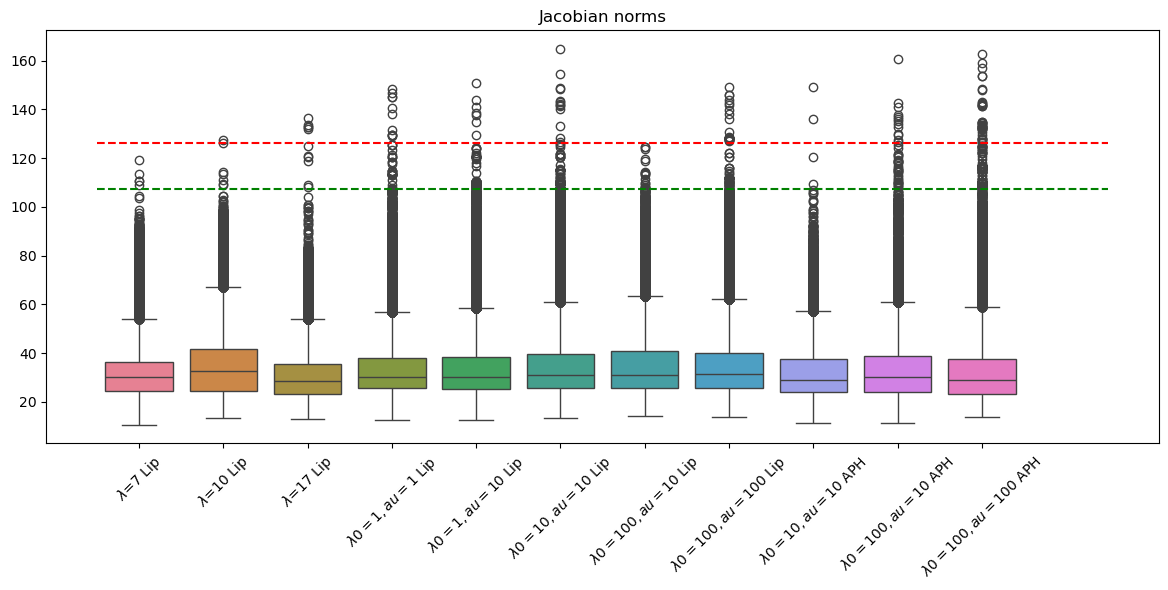

In [83]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_jac_norms)
plt.xticks(rotation=45)
plt.title("Jacobian norms")
plt.tight_layout()
plt.hlines(L_frob_lorenz, xmin=-0.5, xmax=11.5, color='red', linestyle='--', label=r"$Upper L_F$")
plt.hlines(L_effective.max(), xmin=-0.5, xmax=11.5, color='green', linestyle='--', label=r"$L_{eff}$") 
plt.hlines(df_jac_norms["True"].median(), xmin=-0.5, xmax=11.5, color='black', linestyle='--', label=r"$L_{true}$")
plt.legend()
plt.show()

In [73]:
# KL div jacobian norms
# avoid division by zero
epsilon = 1e-10
xmin, xmax = lip_data_lorenz_true.min(), lip_data_lorenz_true.max()
pdf_true_jacs = np.histogram(lip_data_lorenz_true, bins=50, range=[xmin, xmax], density=True)[0] + epsilon
KL_jacs = {}
for col in df_jac_norms.columns:
    pdf_jacs = np.histogram(df_jac_norms[col], bins=50, range=[xmin, xmax], density=True)[0] + epsilon
    KL_jacs[col] = entropy(pdf_jacs, pdf_true_jacs)

In [74]:
KL_jacs

{'$\\lambda$=7 Lip': 1.1688163209376228,
 '$\\lambda$=10 Lip': 1.5401214925419424,
 '$\\lambda$=17 Lip': 0.8657116171123479,
 '$\\lambda0=1, \tau=1$ Lip': 1.2775673219946257,
 '$\\lambda0=1, \tau=10$ Lip': 1.3186637707595874,
 '$\\lambda0=10, \tau=10$ Lip': 1.5140865802820984,
 '$\\lambda0=100, \tau=10$ Lip': 1.4016066781877237,
 '$\\lambda0=100, \tau=100$ Lip': 1.5639879472083225,
 '$\\lambda0=10, \tau=10$ APH': 1.0522299508626172,
 '$\\lambda0=100, \tau=10$ APH': 1.1949520502464606,
 '$\\lambda0=100, \tau=100$ APH': 1.1009083446922705,
 'True': 0.0}

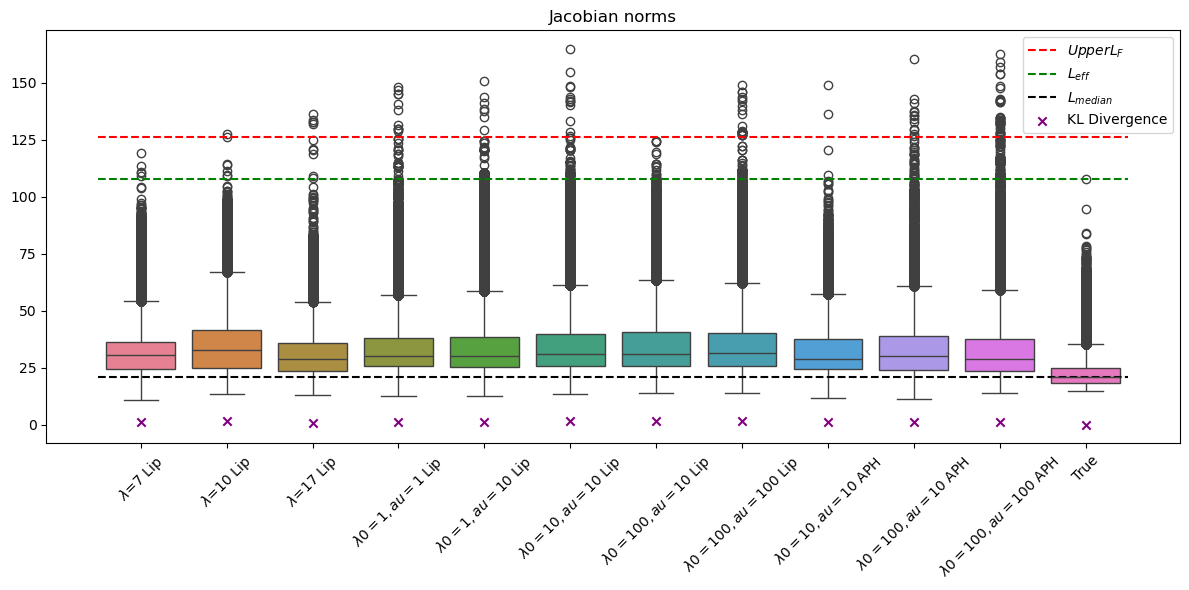

In [78]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_jac_norms)
plt.xticks(rotation=45)
plt.title("Jacobian norms")
plt.tight_layout()
plt.hlines(L_frob_lorenz, xmin=-0.5, xmax=11.5, color='red', linestyle='--', label=r"$Upper L_F$")
plt.hlines(L_effective.max(), xmin=-0.5, xmax=11.5, color='green', linestyle='--', label=r"$L_{eff}$") 
plt.hlines(df_jac_norms["True"].median(), xmin=-0.5, xmax=11.5, color='black', linestyle='--', label=r"$L_{median}$")

# add KL divergences on twin x 

plt.scatter(list(KL_jacs.keys()), list(KL_jacs.values()), color='purple', label='KL Divergence', marker='x')
plt.legend()
#plt.yscale("log")
plt.show()



# Figures poster ELLIS Summer school 09/2025

In [6]:
# L traj
path_05_long = '/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_aug_0.5_12_h8nc71jn/model_8.569e+01_longrun_100.json'
data_05 = pd.read_json(path_05_long).T
data_05 = compute_metrics_lorenz(data_05, compute_phy=True, eps=0.01)

In [7]:
path_model_05 = '/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_aug_0.5_12_h8nc71jn/model_8.569e+01.eqx'
model_05 = load_model_40s('model_8.569e+01.eqx', 'none_aug_0.5_12_h8nc71jn', '/Users/mayajanvier/jax-phynity/data/lorenz_curriculum', "none", True, "lorenz", "RK4", dt_num=0.01, duration=100)
L_traj_05 = compute_jacobian_test(model_05, yL_10s) 
L_traj_05_50s = compute_jacobian_test(model_05, yL_50s)

/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_aug_0.5_12_h8nc71jn/model_8.569e+01.eqx
0.01 1


NameError: name 'yL_10s' is not defined

In [30]:
df_jac_norms = pd.DataFrame({
    # lambda fixed
    # r"$\lambda$=7 Lip": compute_jacobian_test(models_lip05[7], yL_10s),
    # r"$\lambda$=10 Lip": compute_jacobian_test(models_lip05[10], yL_10s),
    r"$\mathcal{L}_{traj}$": L_traj_05,
    r"$\mathcal{R}_F$": compute_jacobian_test(models_aph05_prog["10.0"]["10.0"], yL_10s),
    r"$\mathcal{R}_{Lip_x}$": compute_jacobian_test(models_lip05[17], yL_10s),
    "True": lip_data_lorenz_true,
    # lambda progressive
    # "$\lambda0=1, \tau=1$ Lip": compute_jacobian_test(models_lip05_prog["1.0"]["1.0"], yL_10s),
    # "$\lambda0=1, \tau=10$ Lip": compute_jacobian_test(models_lip05_prog["1.0"]["10.0"], yL_10s),
    # "$\lambda0=10, \tau=10$ Lip": compute_jacobian_test(models_lip05_prog["10.0"]["10.0"], yL_10s),
    # "$\lambda0=100, \tau=10$ Lip": compute_jacobian_test(models_lip05_prog["100.0"]["10.0"], yL_10s),
    # "$\lambda0=100, \tau=100$ Lip": compute_jacobian_test(models_lip05_prog["100.0"]["100.0"], yL_10s),
    
    # "$\lambda0=100, \tau=10$ APH": compute_jacobian_test(models_aph05_prog["100.0"]["10.0"], yL_10s),
    # "$\lambda0=100, \tau=100$ APH": compute_jacobian_test(models_aph05_prog["100.0"]["100.0"], yL_10s)
})

In [31]:
df_jac_norms50s = pd.DataFrame({
    # lambda fixed
    # r"$\lambda$=7 Lip": compute_jacobian_test(models_lip05[7], yL_10s),
    # r"$\lambda$=10 Lip": compute_jacobian_test(models_lip05[10], yL_10s),
    r"$\mathcal{L}_{traj}$": L_traj_05_50s,
    r"$\mathcal{R}_F$": compute_jacobian_test(models_aph05_prog["10.0"]["10.0"], yL_50s),
    r"$\mathcal{R}_{Lip_x}$": compute_jacobian_test(models_lip05[17], yL_50s),
    "True": lip_data_lorenz_true50s,
    # lambda progressive
    # "$\lambda0=1, \tau=1$ Lip": compute_jacobian_test(models_lip05_prog["1.0"]["1.0"], yL_10s),
    # "$\lambda0=1, \tau=10$ Lip": compute_jacobian_test(models_lip05_prog["1.0"]["10.0"], yL_10s),
    # "$\lambda0=10, \tau=10$ Lip": compute_jacobian_test(models_lip05_prog["10.0"]["10.0"], yL_10s),
    # "$\lambda0=100, \tau=10$ Lip": compute_jacobian_test(models_lip05_prog["100.0"]["10.0"], yL_10s),
    # "$\lambda0=100, \tau=100$ Lip": compute_jacobian_test(models_lip05_prog["100.0"]["100.0"], yL_10s),
    
    # "$\lambda0=100, \tau=10$ APH": compute_jacobian_test(models_aph05_prog["100.0"]["10.0"], yL_10s),
    # "$\lambda0=100, \tau=100$ APH": compute_jacobian_test(models_aph05_prog["100.0"]["100.0"], yL_10s)
})

In [45]:
palette = ['mediumslateblue', 'lightgreen','hotpink']

df_bestX = pd.DataFrame({
    # lambda fixed
    r"$\mathcal{L}_{traj}$": data_05["KL_x"], # L traj curriculum 
    #r"$\lambda$=7 Lip": data_lip05[7][f"KL_x"],
    #r"$\lambda$=10 Lip": data_lip05[10][f"KL_x"],
    r"$\mathcal{R}_F$": data_aph05_prog["10.0"]["10.0"][f"KL_x"],  # best APH model
    r"$\mathcal{R}_{Lip_x}$": data_lip05[17][f"KL_x"], # best Lip model
    # lambda progressive
    # "$\lambda0=1, \tau=1$ Lip": data_lip05_prog["1.0"]["1.0"][f"KL_x"], 
    # "$\lambda0=1, \tau=10$ Lip": data_lip05_prog["1.0"]["10.0"][f"KL_x"], 
    # "$\lambda0=10, \tau=10$ Lip": data_lip05_prog["10.0"]["10.0"][f"KL_x"],
    # "$\lambda0=100, \tau=10$ Lip": data_lip05_prog["100.0"]["10.0"][f"KL_x"],
    # "$\lambda0=100, \tau=100$ Lip": data_lip05_prog["100.0"]["100.0"][f"KL_x"],
    
    # "$\lambda0=100, \tau=10$ APH": data_aph05_prog["100.0"]["10.0"][f"KL_x"], 
    # "$\lambda0=100, \tau=100$ APH": data_aph05_prog["100.0"]["100.0"][f"KL_x"]
})

AttributeError: 'Axes' object has no attribute 'tight_layout'

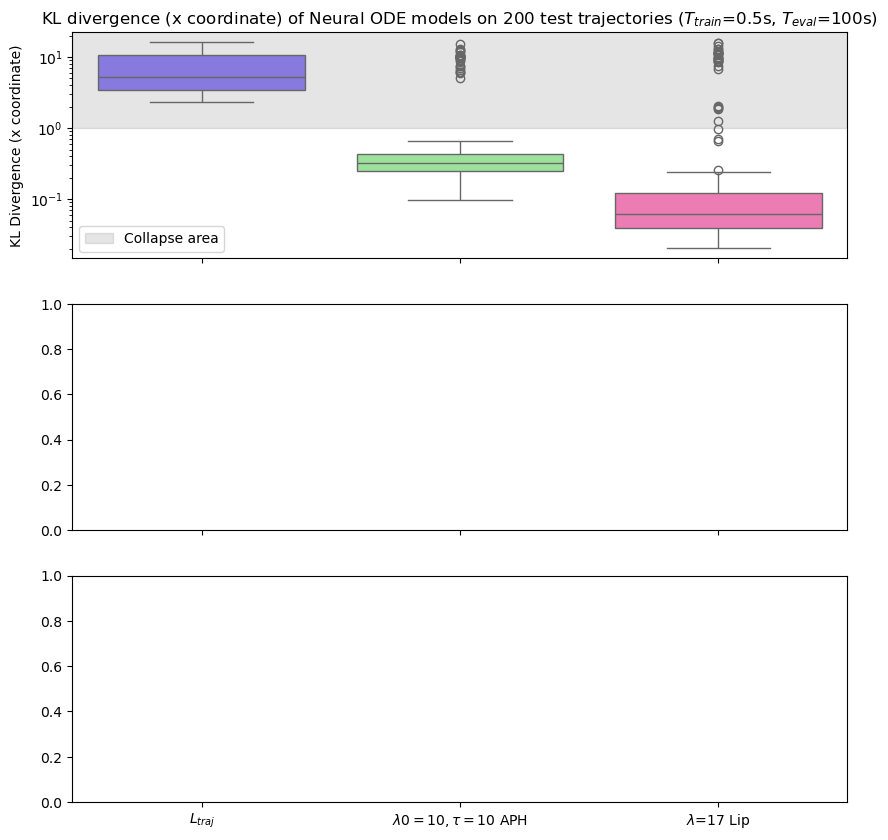

In [89]:
fig, ax = plt.subplots(3,1, figsize=(10, 10), sharex="all")


# KL div x
ax[0].fill_between([-0.5, 2.5],1, 5e1, label="Collapse area", color='black', alpha=0.1)
sns.boxplot(data=df_bestX, palette=palette, ax=ax[0])
ax[0].set_yscale('log')
ax[0].set_ylabel("KL Divergence (x coordinate)")
ax[0].set_xticks([0,1,2])
ax[0].set_title(r"KL divergence (x coordinate) of Neural ODE models on 200 test trajectories ($T_{train}$=0.5s, $T_{eval}$=100s)")
ax[0].legend()
ax[0].tight_layout()

# trajectories
ax[1].plot(data_05["y_true"][63][0,:], color="blue", label="True trajectory")
ax[1].plot(data_05["y_pred"][63][0,:], color="orange", label="Predicted trajectory")
ax[1].set_ylabel("X coordinate")
ax[1].set_title("Example of trajectory prediction for the best curriculum model")


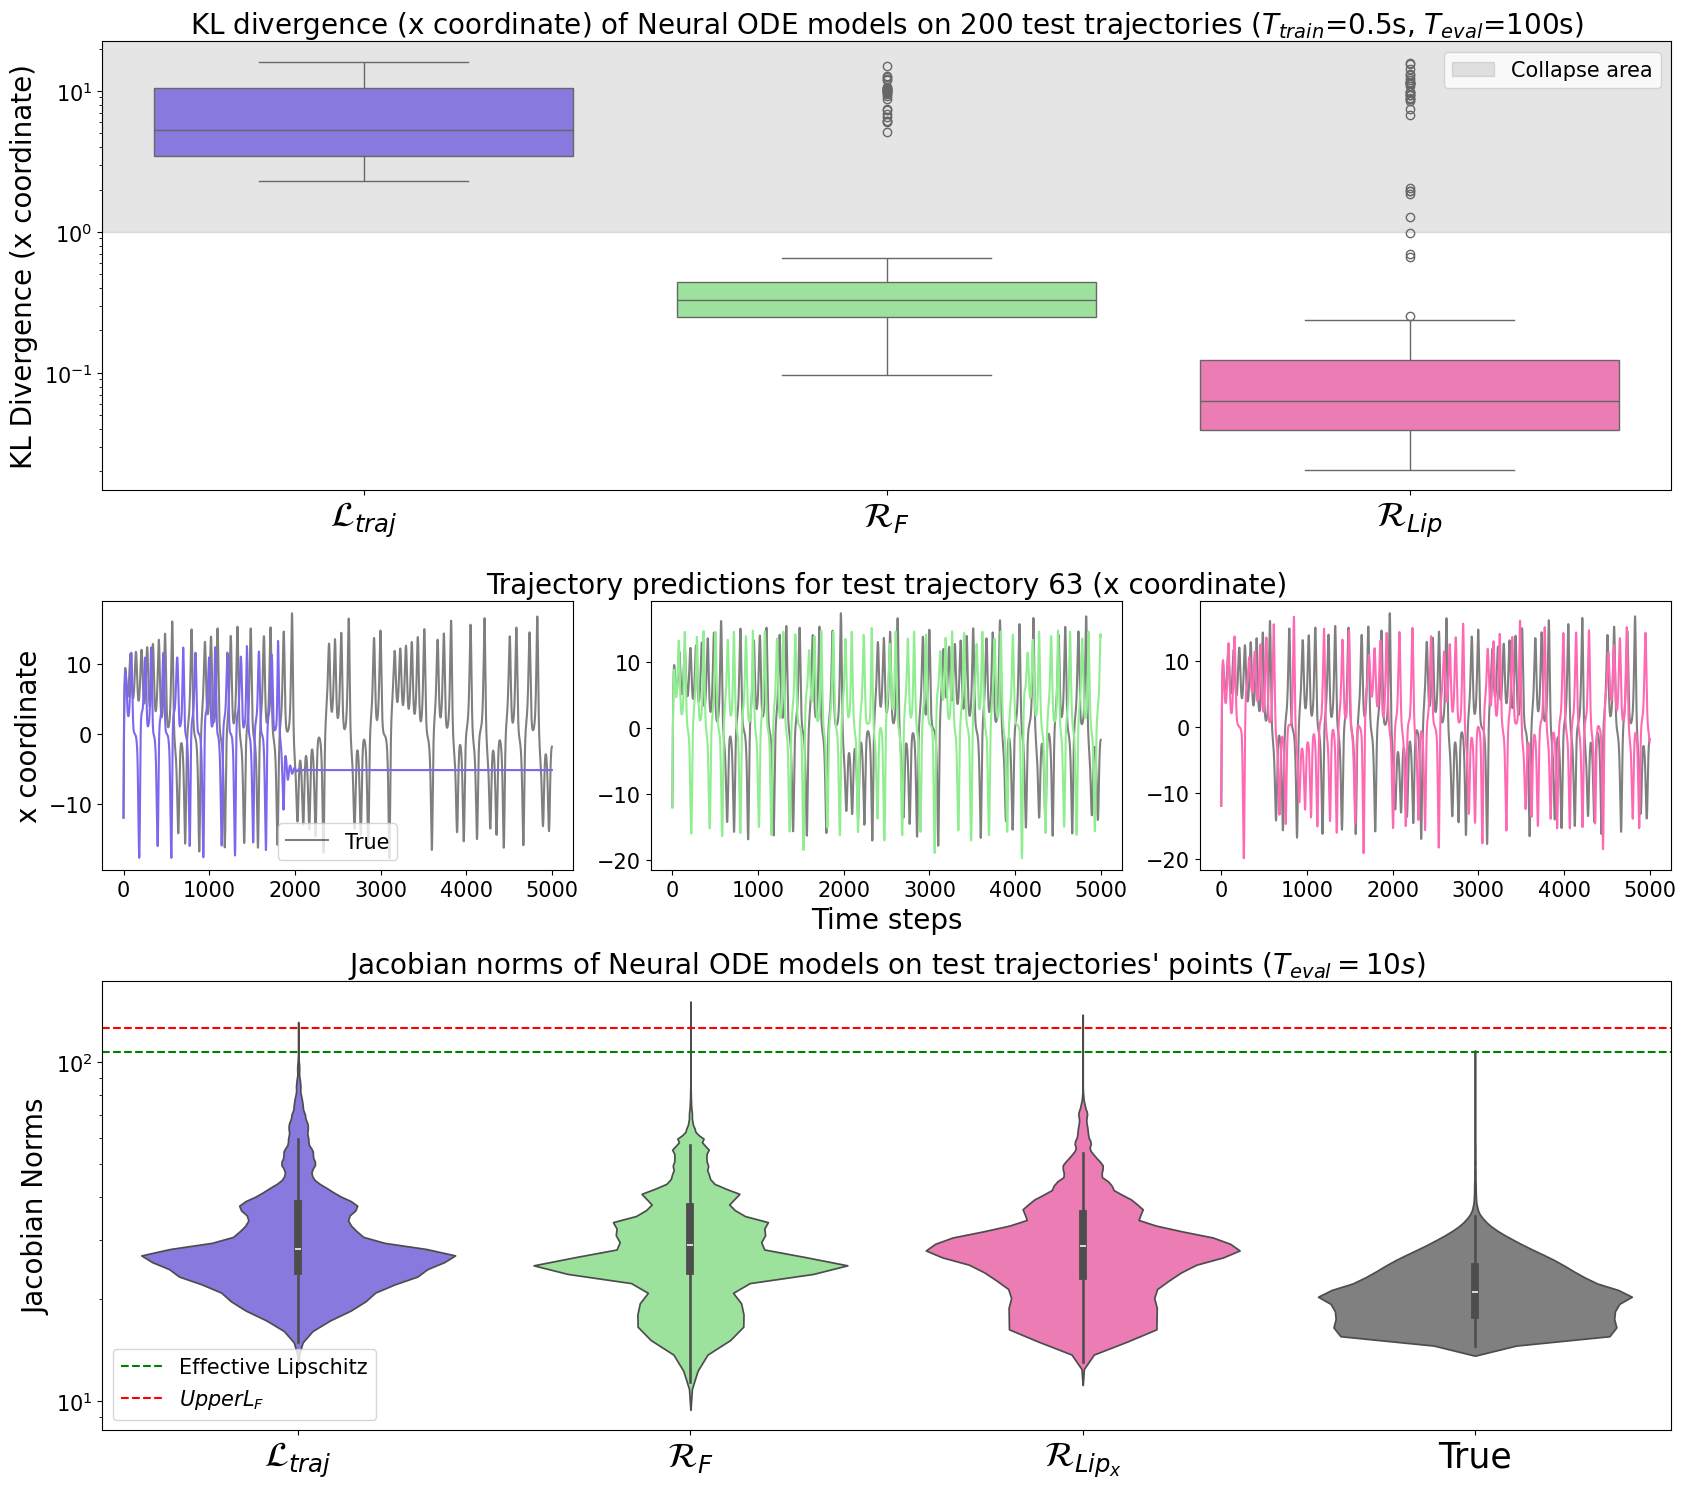

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

import matplotlib as mpl

fontsize_titles = 20
fontsize_legend = 15

mpl.rcParams['axes.titlesize'] = fontsize_titles     # subplot titles
mpl.rcParams['axes.labelsize'] = fontsize_titles # x/y labels
mpl.rcParams['legend.fontsize'] = fontsize_legend   # legends
mpl.rcParams['xtick.labelsize'] = fontsize_legend   # x tick labels
mpl.rcParams['ytick.labelsize'] = fontsize_legend   # y tick labels

fig = plt.figure(figsize=(17, 15))
gs = GridSpec(3, 3, figure=fig, height_ratios=[1, 0.6, 1])  

palette = ['mediumslateblue', 'lightgreen','hotpink']

# -------------------
# KL divergence boxplot (row 0 spanning all 3 cols)
# -------------------
ax_box = fig.add_subplot(gs[0, :])
ax_box.fill_between([-0.5, 2.5], 1, 5e1, label="Collapse area", color='black', alpha=0.1)
sns.boxplot(data=df_bestX, palette=palette, ax=ax_box)
ax_box.set_yscale('log')
ax_box.set_ylabel("KL Divergence (x coordinate)")
ax_box.set_xticks([0,1,2])
ax_box.tick_params(axis="x", labelsize=25)
ax_box.set_title(r"KL divergence (x coordinate) of Neural ODE models on 200 test trajectories ($T_{train}$=0.5s, $T_{eval}$=100s)")
ax_box.legend()

# -------------------
# Trajectory plots (row 1: three subplots side by side)
# -------------------
axes_traj = [fig.add_subplot(gs[1, i]) for i in range(3)]

models = {
    "Curriculum": (data_05["y_true"][63][0,:], data_05["y_pred"][63][0,:]),
    "APH": (data_aph05_prog["10.0"]["10.0"]["y_true"][63][0,:], data_aph05_prog["10.0"]["10.0"]["y_pred"][63][0,:]),
    "Lip": (data_lip05[17]["y_true"][63][0,:], data_lip05[17]["y_pred"][63][0,:])
}

for i, (ax_, (name, (y_true, y_pred))) in enumerate(zip(axes_traj, models.items())):
    ax_.plot(y_true[:5000], color="black", label="True", alpha=0.5)
    ax_.plot(y_pred[:5000], color=palette[i])
    if i == 0 :
        ax_.set_ylabel("x coordinate")
    if i==1:
        ax_.set_xlabel("Time steps")
    #ax_.set_title(name)

axes_traj[0].legend()
ax_title = fig.add_subplot(gs[1, :])  # spans entire middle row
ax_title.axis("off")  # hide everything
ax_title.set_title("Trajectory predictions for test trajectory 63 (x coordinate)")


# -------------------
# Jacobian norms plots (row 2: one subplot spanning all 3 cols)
# -------------------
ax_jac = fig.add_subplot(gs[2, :])
ax_jac.hlines(L_effective.max(),xmin=-0.5, xmax=3.5 , label="Effective Lipschitz", color='green',linestyle='--')
ax_jac.hlines(L_frob_lorenz, xmin=-0.5, xmax=3.5, color='red', linestyle='--', label=r"$Upper L_F$")
#ax_jac.hlines(jnp.median(lip_data_lorenz_true), xmin=-0.5, xmax=3.5, color='black', linestyle='--', label=r"$L_{median}$")

sns.violinplot(data=df_jac_norms, palette=palette+["grey"], ax=ax_jac)
ax_jac.set_ylabel("Jacobian Norms")
ax_jac.set_yscale('log')
ax_jac.tick_params(axis="x", labelsize=25)
ax_jac.set_title(r"Jacobian norms of Neural ODE models on test trajectories' points ($T_{eval}=10s$)")
ax_jac.legend(loc='lower left')


plt.tight_layout()
plt.show()


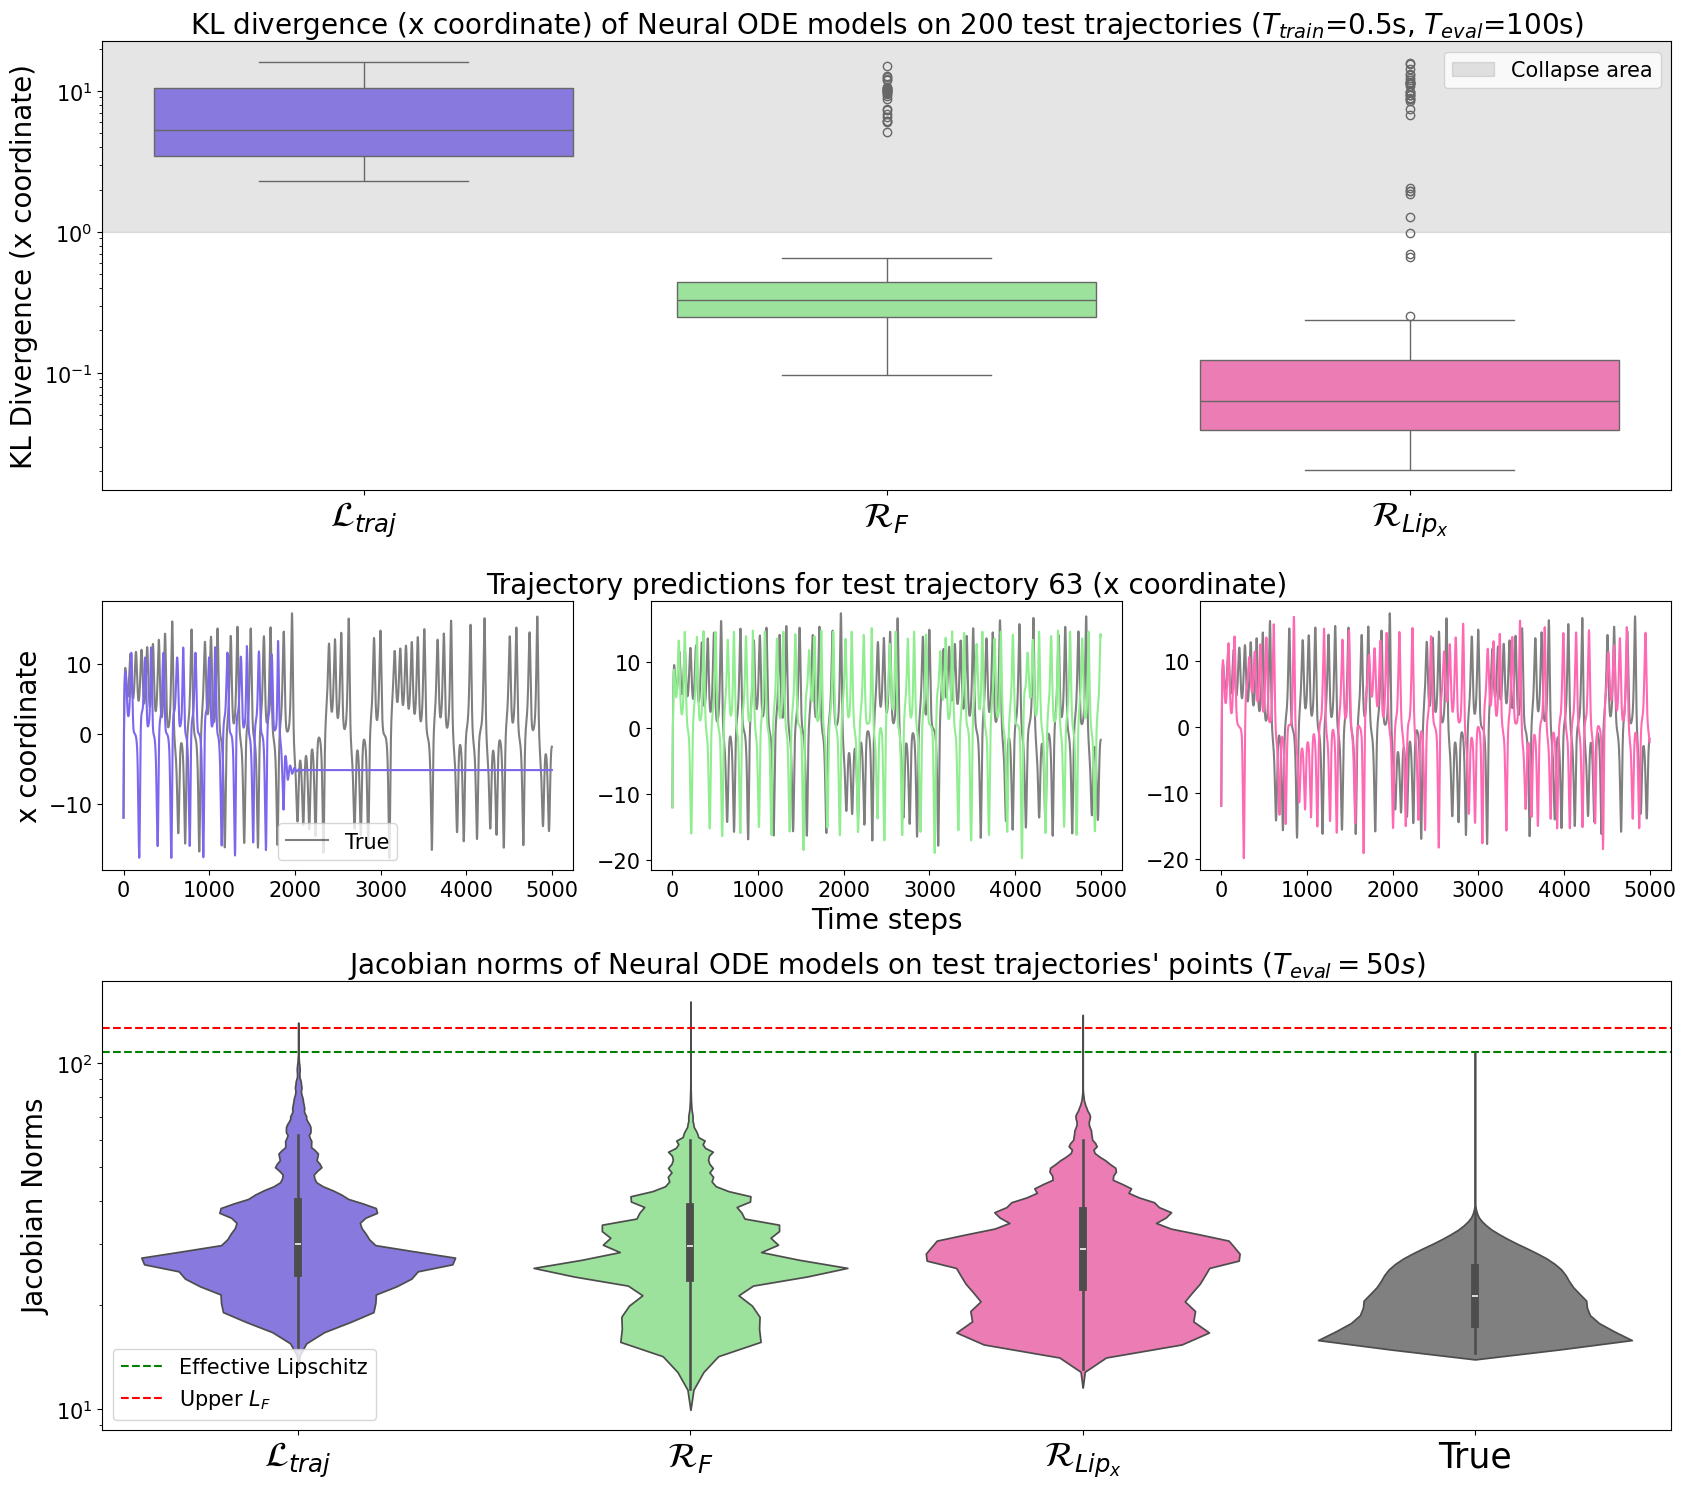

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

import matplotlib as mpl

fontsize_titles = 20
fontsize_legend = 15

mpl.rcParams['axes.titlesize'] = fontsize_titles     # subplot titles
mpl.rcParams['axes.labelsize'] = fontsize_titles # x/y labels
mpl.rcParams['legend.fontsize'] = fontsize_legend   # legends
mpl.rcParams['xtick.labelsize'] = fontsize_legend   # x tick labels
mpl.rcParams['ytick.labelsize'] = fontsize_legend   # y tick labels

fig = plt.figure(figsize=(17, 15))
gs = GridSpec(3, 3, figure=fig, height_ratios=[1, 0.6, 1])  

palette = ['mediumslateblue', 'lightgreen','hotpink']

# -------------------
# KL divergence boxplot (row 0 spanning all 3 cols)
# -------------------
ax_box = fig.add_subplot(gs[0, :])
ax_box.fill_between([-0.5, 2.5], 1, 5e1, label="Collapse area", color='black', alpha=0.1)
sns.boxplot(data=df_bestX, palette=palette, ax=ax_box)
ax_box.set_yscale('log')
ax_box.set_ylabel("KL Divergence (x coordinate)")
ax_box.set_xticks([0,1,2])
ax_box.tick_params(axis="x", labelsize=25)
ax_box.set_title(r"KL divergence (x coordinate) of Neural ODE models on 200 test trajectories ($T_{train}$=0.5s, $T_{eval}$=100s)")
ax_box.legend()

# -------------------
# Trajectory plots (row 1: three subplots side by side)
# -------------------
axes_traj = [fig.add_subplot(gs[1, i]) for i in range(3)]

models = {
    "Curriculum": (data_05["y_true"][63][0,:], data_05["y_pred"][63][0,:]),
    "APH": (data_aph05_prog["10.0"]["10.0"]["y_true"][63][0,:], data_aph05_prog["10.0"]["10.0"]["y_pred"][63][0,:]),
    "Lip": (data_lip05[17]["y_true"][63][0,:], data_lip05[17]["y_pred"][63][0,:])
}

for i, (ax_, (name, (y_true, y_pred))) in enumerate(zip(axes_traj, models.items())):
    ax_.plot(y_true[:5000], color="black", label="True", alpha=0.5)
    ax_.plot(y_pred[:5000], color=palette[i])
    if i == 0 :
        ax_.set_ylabel("x coordinate")
    if i==1:
        ax_.set_xlabel("Time steps")
    #ax_.set_title(name)

axes_traj[0].legend()
ax_title = fig.add_subplot(gs[1, :])  # spans entire middle row
ax_title.axis("off")  # hide everything
ax_title.set_title("Trajectory predictions for test trajectory 63 (x coordinate)")


# -------------------
# Jacobian norms plots (row 2: one subplot spanning all 3 cols)
# -------------------
ax_jac = fig.add_subplot(gs[2, :])
ax_jac.hlines(L_effective.max(),xmin=-0.5, xmax=3.5 , label="Effective Lipschitz", color='green',linestyle='--')
ax_jac.hlines(L_frob_lorenz, xmin=-0.5, xmax=3.5, color='red', linestyle='--', label=r"Upper $L_F$")

#ax_jac.hlines(jnp.median(lip_data_lorenz_true), xmin=-0.5, xmax=3.5, color='black', linestyle='--', label=r"$L_{median}$")

sns.violinplot(data=df_jac_norms50s, palette=palette+["grey"], ax=ax_jac)

# add KL_jax values

ax_jac.set_ylabel("Jacobian Norms")
ax_jac.set_yscale('log')
ax_jac.tick_params(axis="x", labelsize=25)
ax_jac.set_title(r"Jacobian norms of Neural ODE models on test trajectories' points ($T_{eval}=50s$)")
ax_jac.legend(loc='lower left')


plt.tight_layout()
plt.show()


In [44]:
for col in df_jac_norms50s.columns:
    print(col, np.mean(np.abs(df_jac_norms50s[col]- lip_data_lorenz_true50s)))
    print(col, KL_jacs[col])

$\mathcal{L}_{traj}$ 13.129899
$\mathcal{L}_{traj}$ 1.8729442718823204
$\mathcal{R}_F$ 10.034484
$\mathcal{R}_F$ 1.4459466881049554
$\mathcal{R}_{Lip_x}$ 9.599648
$\mathcal{R}_{Lip_x}$ 1.276790362610539
True 0.0
True 0.0


In [37]:
epsilon = 1e-10
xmin, xmax = lip_data_lorenz_true50s.min(), lip_data_lorenz_true50s.max()
pdf_true_jacs = np.histogram(lip_data_lorenz_true50s, bins=50, range=[xmin, xmax], density=True)[0] + epsilon
KL_jacs = {}
for col in df_jac_norms50s.columns:
    pdf_jacs = np.histogram(df_jac_norms50s[col], bins=50, range=[xmin, xmax], density=True)[0] + epsilon
    KL_jacs[col] = entropy(pdf_jacs, pdf_true_jacs)

In [38]:
KL_jacs

{'$\\mathcal{L}_{traj}$': 1.8729442718823204,
 '$\\mathcal{R}_F$': 1.4459466881049554,
 '$\\mathcal{R}_{Lip_x}$': 1.276790362610539,
 'True': 0.0}

In [48]:
epsilon = 1e-10
xmin, xmax = lip_data_lorenz_true50s.min(), lip_data_lorenz_true50s.max()
pdf_true_jacs = np.histogram(lip_data_lorenz_true50s, bins=50, range=[xmin, xmax], density=True)[0] + epsilon
KL_jacsrev = {}
for col in df_jac_norms50s.columns:
    pdf_jacs = np.histogram(df_jac_norms50s[col], bins=50, range=[xmin, xmax], density=True)[0] + epsilon
    KL_jacsrev[col] = entropy(pdf_true_jacs,pdf_jacs)
KL_jacsrev

{'$\\mathcal{L}_{traj}$': 1.0035135051425048,
 '$\\mathcal{R}_F$': 0.6045421619538969,
 '$\\mathcal{R}_{Lip_x}$': 0.49763132013482136,
 'True': 0.0}

## dt influence

In [5]:
def load_model_dt(model_name,exp_name, data_path, model_phy_option, model_aug_option, dataset_name, integration_method, dt,  data_integration_method="RK4", dt_num=0.5, duration=40):
    """Compute trajectory losses and Fa loss for a given model, on its duration of training data."""
    # load test data 
    _, _, test = init_dataloaders(dataset_name, data_integration_method, os.path.join(data_path, dataset_name+str(duration)+"_"+str(dt_num)), dt_num=dt_num, duration=duration)

    # load model
    model_path = os.path.join(data_path, f"{exp_name}/{model_name}")
    print(model_path)
    dt = dt
    dt_factor = int(dt/test.dataset.dt)
    print(dt, dt_factor)
    if dataset_name == 'pendulum':
        if model_phy_option == 'true': # true damped pendulum
            model_phy = PendulumParamPDE(is_damped=True, params=test.dataset.params, is_true=True)
        elif model_phy_option == 'complete': # damped pendulum
            model_phy = PendulumParamPDE(is_damped=True)
        else: 
            model_phy = PendulumParamPDE(is_damped=False)
    
        with open(model_path, "rb") as f:
            hyperparams = json.loads(f.readline().decode())
            mkey = jax.random.PRNGKey(0)
            model_aug = MLP(key=mkey, state_c=2, hidden=200)
            net = Forecaster(
                model_phy=model_phy,
                model_aug=model_aug,
                is_augmented=model_aug_option,
                is_phy=model_phy_option,
                dt=dt,
                num_steps=int(test.dataset.num_steps/dt_factor),
                integration_method=integration_method, # error scheme exp
            )
            model = eqx.tree_deserialise_leaves(f, net)
    elif dataset_name == "lorenz":
        model_phy = None # Neural ODE 
        with open(model_path, "rb") as f:
            hyperparams = json.loads(f.readline().decode())
            mkey, ikey = jax.random.split(jax.random.PRNGKey(0))
            model_aug = MLP(key=mkey, state_c=3, hidden=200)
            net = Forecaster(
                model_phy=model_phy,
                model_aug=model_aug,
                is_augmented=model_aug_option,
                is_phy=model_phy_option,
                dt=dt_factor * test.dataset.dt, # enabling comparison with GT for error scheme experiment 
                num_steps=int(test.dataset.num_steps / dt_factor), 
                integration_method=integration_method, # RK2 for error scheme experiment
            )
            model = eqx.tree_deserialise_leaves(f, net)
    return model

In [6]:
dt, dt_num = 0.01, 0.01
model_05_001 = load_model_dt('model_8.569e+01.eqx', 'none_aug_0.5_12_h8nc71jn', '/Users/mayajanvier/jax-phynity/data/lorenz_curriculum', "none", True, "lorenz", "RK4",dt=dt,  dt_num=dt_num, duration=100)
dt, dt_num = 0.001, 0.001
model_05_0001 = load_model_dt('model_8.569e+01.eqx', 'none_aug_0.5_12_h8nc71jn', '/Users/mayajanvier/jax-phynity/data/lorenz_curriculum', "none", True, "lorenz", "RK4", dt=dt, dt_num=dt_num, duration=100)


/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_aug_0.5_12_h8nc71jn/model_8.569e+01.eqx
0.01 1
/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_aug_0.5_12_h8nc71jn/model_8.569e+01.eqx
0.001 1


In [7]:
# Enable 64-bit precision in JAX
jax.config.update("jax_enable_x64", True)

In [31]:
y0 = jnp.array(data_05["y_true"][0][:,0], dtype=jnp.float64)
output_05_001 = model_05_001(y0)
output_05_0001 = model_05_0001(y0)

In [103]:
def generate_trajectories(model,dt,duration =100, dataset_name="lorenz"):
    
    _,_,test = init_dataloaders(dataset_name, "RK4", os.path.join("data/lorenz_curriculum", dataset_name+str(duration)+"_"+str(dt)), dt_num=dt, duration=100)
    results_dic = {}
    for i, data in enumerate(test):
        states = jnp.array(data['states'], dtype=jnp.float64)
        #print(states.shape)
        y0 = states[0,:,0]
        y_pred = model(y0)
        #y_preds.append(y_pred)
        #y_true.append(states)
        pred_i = {
            'y_true': np.array(states[0]),
            'y_pred': np.array(y_pred),
            #'loss_traj': loss_val.item(),
            #'loss_op': loss_op.item(),
        }
        results_dic[i] = pred_i
#
    return results_dic

In [35]:
data_05["y0"] = data_05.apply(lambda row: jnp.array(row['y_true'][:,0], dtype=jnp.float64), axis=1)

In [104]:
out_05_001_dict = generate_trajectories(model_05_001, 0.01)#, f'/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_aug_0.5_12_h8nc71jn/model_8.569e+01_001_longrun_{dt}.json')

In [120]:
out_05_0001_dict = generate_trajectories(model_05_0001, 0.001)

In [105]:
df_05_001 = pd.DataFrame(out_05_001_dict).T
df_05_001

,y_true,y_pred
0,"[[10.19781628301651, 8.32075272110259, 6.63483...","[[10.19781628301651, 8.039007670903883, 6.1325..."
1,"[[-27.315414428259924, -22.436878170773053, -1...","[[-27.315414428259924, -21.64418181080288, -16..."
2,"[[-11.759277850901666, -12.12776383653325, -12...","[[-11.759277850901666, -11.884324832872293, -1..."
3,"[[24.058513023132228, 22.47001151549106, 21.91...","[[24.058513023132228, 21.201749361191805, 19.7..."
4,"[[23.794790696516653, 23.362850715683265, 22.7...","[[23.794790696516653, 23.534158812231627, 23.1..."
...,...,...
195,"[[13.726586779889436, 12.688495644871413, 11.6...","[[13.726586779889436, 12.79761129507625, 11.82..."
196,"[[-37.381578261327874, -35.73410681379259, -34...","[[-37.381578261327874, -36.28859057404305, -36..."
197,"[[19.522710975483243, 16.02535074349808, 12.86...","[[19.522710975483243, 15.900521089895784, 12.6..."
198,"[[32.62393803378973, 28.73257875071712, 25.126...","[[32.62393803378973, 28.501240917953993, 24.90..."


In [107]:
df_05_001 = compute_metrics_lorenz(df_05_001, compute_phy=True, eps=0.01)

In [109]:
# save to json
df_05_001.to_json(f'/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_aug_0.5_12_h8nc71jn/model_8.569e+01_longrun_dt=0.01.json')

<Axes: >

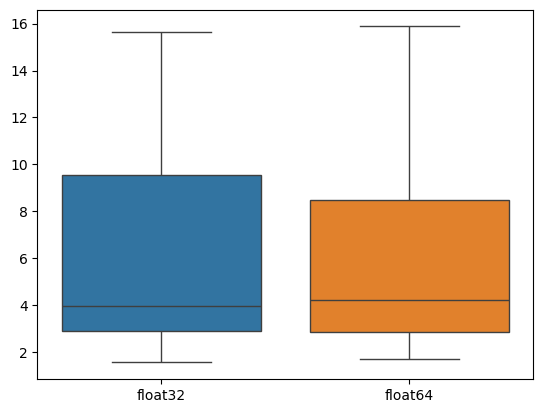

In [119]:
sns.boxplot({
    "float32": data_05["KL_z"],
    "float64": df_05_001["KL_z"]
})

In [15]:
df_05_001 = pd.read_json(f'/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_aug_0.5_12_h8nc71jn/model_8.569e+01_longrun_dt=0.01.json')
df_05_0005 = pd.read_json("/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_aug_0.5_12_h8nc71jn/model_8.569e+01_longrun_dt_100_0.005.json").T

In [16]:
df_05_0005 = compute_metrics_lorenz(df_05_0005, compute_phy=True, eps=0.01)

Text(0.5, 1.0, 'Neural ODE Lorenz, 200 test trajectories (T_eval=100s)')

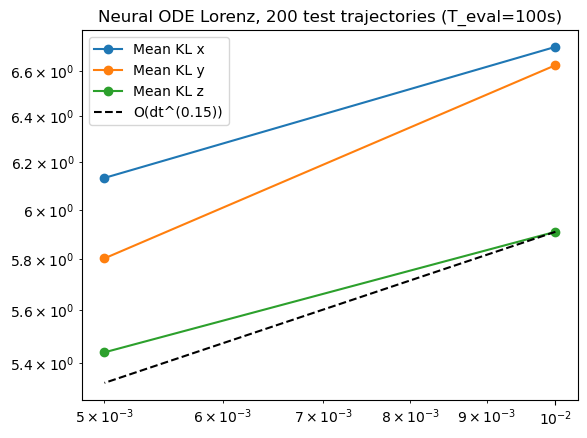

In [39]:
dt_list = np.array([0.01, 0.005])
plt.plot(dt_list, [df_05_001["KL_x"].mean(), df_05_0005["KL_x"].mean()], label="Mean KL x", marker='o')
plt.plot(dt_list, [df_05_001["KL_y"].mean(), df_05_0005["KL_y"].mean()], label="Mean KL y", marker='o')
plt.plot(dt_list, [df_05_001["KL_z"].mean(), df_05_0005["KL_z"].mean()], label="Mean KL z", marker='o')
plt.plot(dt_list, (df_05_001["KL_z"].mean())/(dt_list[0]**0.15)*dt_list**0.15, label="O(dt^(0.15))", linestyle='--', color='black')
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.title("Neural ODE Lorenz, 200 test trajectories (T_eval=100s)")


In [3]:
df_05_005 = pd.read_json("/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_aug_0.5_12_h8nc71jn/model_8.569e+01_longrun_dt_100_0.05.json").T
df_05_001 = pd.read_json("/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_aug_0.5_12_h8nc71jn/model_8.569e+01_longrun_dt_100_0.01.json").T
df_05_0005 = pd.read_json("/Users/mayajanvier/jax-phynity/data/lorenz_curriculum/none_aug_0.5_12_h8nc71jn/model_8.569e+01_longrun_dt_100_0.005.json").T

In [6]:
df_05_005 = compute_metrics_lorenz(df_05_005, compute_phy=True, eps=0.01)
df_05_001 = compute_metrics_lorenz(df_05_001, compute_phy=True, eps=0.01)
df_05_0005 = compute_metrics_lorenz(df_05_0005, compute_phy=True, eps=0.01)

In [59]:
df_05_005["y0"] = df_05_005.apply(lambda row: jnp.array(row['y_true'][:,0], dtype=jnp.float64), axis=1)
df_05_001["y0"] = df_05_001.apply(lambda row: jnp.array(row['y_true'][:,0], dtype=jnp.float64), axis=1)
df_05_0005["y0"] = df_05_0005.apply(lambda row: jnp.array(row['y_true'][:,0], dtype=jnp.float64), axis=1)

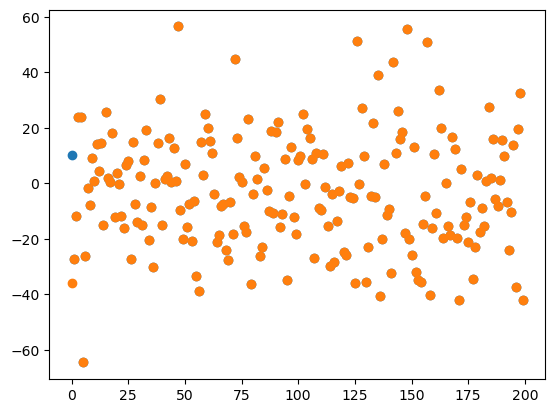

In [61]:
plt.scatter(np.arange(200), [df_05_001["y0"][k][0] for k in range(200)], label="dt=0.05")
plt.scatter(np.arange(200), [df_05_0005["y0"][k][0] for k in range(200)], label="dt=0.01")

In [7]:
df_05_lip_001 = pd.read_json("/Users/mayajanvier/jax-phynity/data/lorenz_curriculum_gridsearch/none_Fa_prime_supX_aug_0.5_64_q3q9xbrk/model_7.160e+01_longrun_dt_100_0.01.json").T
df_05_lip_005 = pd.read_json("/Users/mayajanvier/jax-phynity/data/lorenz_curriculum_gridsearch/none_Fa_prime_supX_aug_0.5_64_q3q9xbrk/model_7.160e+01_longrun_dt_100_0.05.json").T
df_05_lip_0005 = pd.read_json("/Users/mayajanvier/jax-phynity/data/lorenz_curriculum_gridsearch/none_Fa_prime_supX_aug_0.5_64_q3q9xbrk/model_7.160e+01_longrun_dt_100_0.005.json").T

In [9]:
df_05_lip_001 = compute_metrics_lorenz(df_05_lip_001, compute_phy=True, eps=0.01)
df_05_lip_005 = compute_metrics_lorenz(df_05_lip_005, compute_phy=True, eps=0.01)
df_05_lip_0005 = compute_metrics_lorenz(df_05_lip_0005, compute_phy=True, eps=0.01)

In [8]:
df_05_Fa_0005 = pd.read_json("/Users/mayajanvier/jax-phynity/data/lorenz_curriculum_gridsearch/none_Fa_aug_0.5_96_q3q9xbrk/model_8.008e+01_longrun_dt_100_0.005.json").T
df_05_Fa_001 = pd.read_json("/Users/mayajanvier/jax-phynity/data/lorenz_curriculum_gridsearch/none_Fa_aug_0.5_96_q3q9xbrk/model_8.008e+01_longrun_dt_100_0.01.json").T
df_05_Fa_005 = pd.read_json("/Users/mayajanvier/jax-phynity/data/lorenz_curriculum_gridsearch/none_Fa_aug_0.5_96_q3q9xbrk/model_8.008e+01_longrun_dt_100_0.05.json").T

df_05_Fa_0005 = compute_metrics_lorenz(df_05_Fa_0005, compute_phy=True, eps=0.01)
df_05_Fa_001 = compute_metrics_lorenz(df_05_Fa_001, compute_phy=True, eps=0.01)
df_05_Fa_005 = compute_metrics_lorenz(df_05_Fa_005, compute_phy=True, eps=0.01)

In [67]:
df_05_lip_005["y0"] = df_05_lip_005.apply(lambda row: jnp.array(row['y_true'][:,0], dtype=jnp.float64), axis=1)
df_05_lip_001["y0"] = df_05_lip_001.apply(lambda row: jnp.array(row['y_true'][:,0], dtype=jnp.float64), axis=1)
df_05_lip_0005["y0"] = df_05_lip_0005.apply(lambda row: jnp.array(row['y_true'][:,0], dtype=jnp.float64), axis=1)


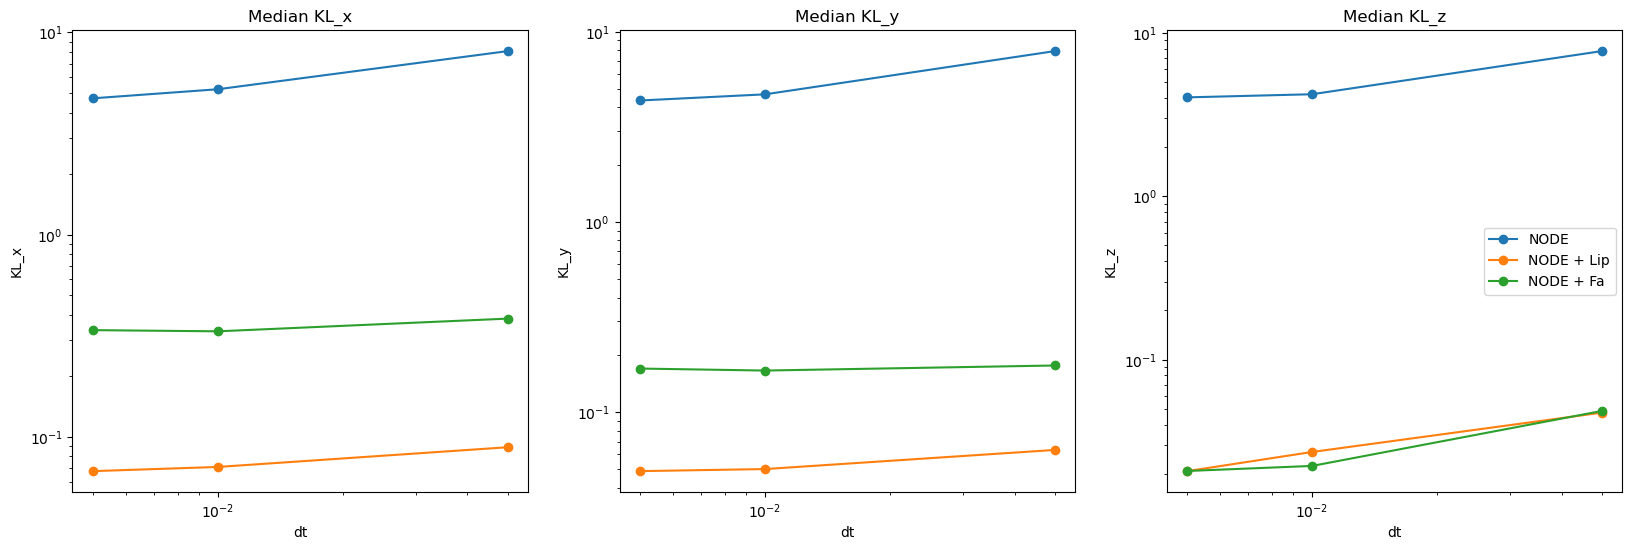

In [10]:
dt_list = np.array([0.05, 0.01, 0.005])
fig, ax = plt.subplots(1,3, figsize=(20,6))
metrics = ["KL_x", "KL_y", "KL_z"]
for k in range(len(metrics)):
    metric = metrics[k]
    ax[k].plot(dt_list, [df_05_005[metric].median(),df_05_001[metric].median(), df_05_0005[metric].median()], label="NODE", marker='o')
    ax[k].plot(dt_list, [df_05_lip_005[metric].median(),df_05_lip_001[metric].median(), df_05_lip_0005[metric].median()], label="NODE + Lip", marker='o')
    ax[k].plot(dt_list, [df_05_Fa_005[metric].median(),df_05_Fa_001[metric].median(), df_05_Fa_0005[metric].median()], label="NODE + Fa", marker='o')
    ax[k].set_xscale("log")
    ax[k].set_yscale("log")
    ax[k].set_title(f"Median {metric}")
    ax[k].set_xlabel("dt")
    ax[k].set_ylabel(metric)

plt.legend()

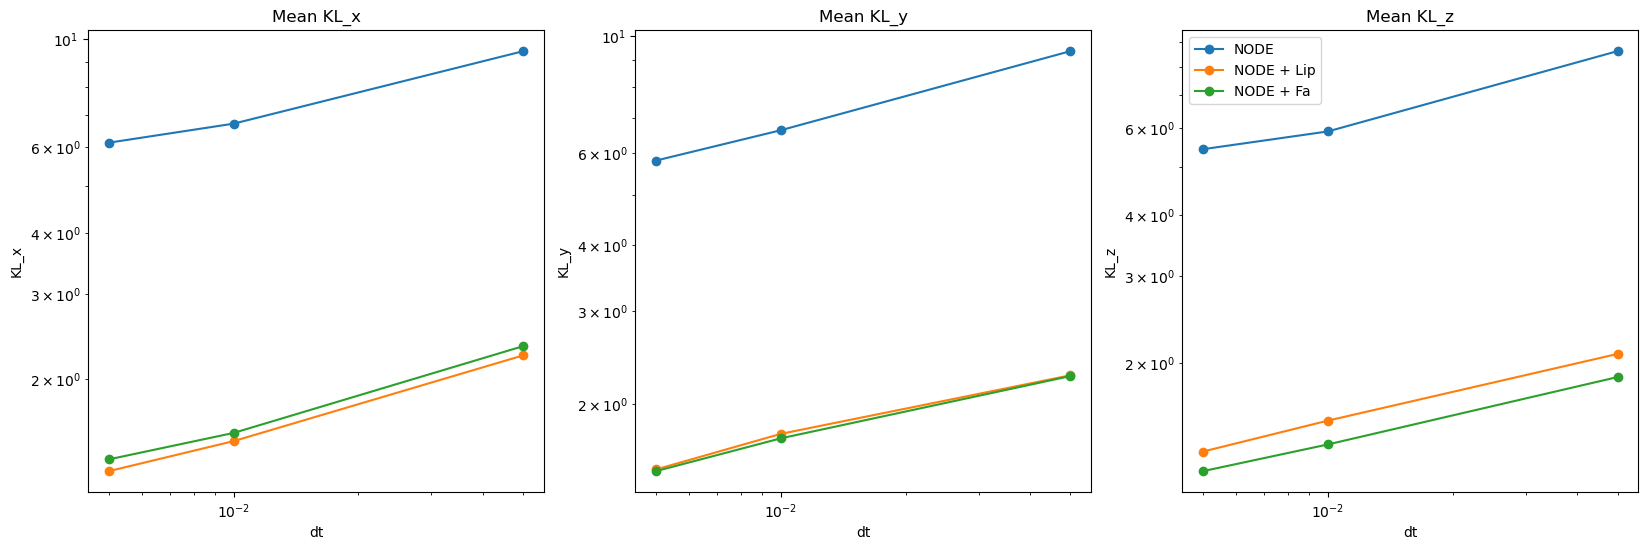

In [77]:
dt_list = np.array([0.05, 0.01, 0.005])
fig, ax = plt.subplots(1,3, figsize=(20,6))
metrics = ["KL_x", "KL_y", "KL_z"]
for k in range(len(metrics)):
    metric = metrics[k]
    ax[k].plot(dt_list, [df_05_005[metric].mean(),df_05_001[metric].mean(), df_05_0005[metric].mean()], label="NODE", marker='o')
    ax[k].plot(dt_list, [df_05_lip_005[metric].mean(),df_05_lip_001[metric].mean(), df_05_lip_0005[metric].mean()], label="NODE + Lip", marker='o')
    ax[k].plot(dt_list, [df_05_Fa_005[metric].mean(),df_05_Fa_001[metric].mean(), df_05_Fa_0005[metric].mean()], label="NODE + Fa", marker='o')
    ax[k].set_xscale("log")
    ax[k].set_yscale("log")
    ax[k].set_title(f"Mean {metric}")
    ax[k].set_xlabel("dt")
    ax[k].set_ylabel(metric)

plt.legend()
